# Проект «Работа с заботой»

# Описание проекта

       HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.
    Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 
    Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 
    У нас будет несколько задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
    Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.
    Наша вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.
    
    Теперь расскажу подробнее о задачах.
    Задача 1: предсказание уровня удовлетворённости сотрудника
    Для этой задачи заказчик предоставил данные с признаками:
* id — уникальный идентификатор сотрудника;
* dept — отдел, в котором работает сотрудник;
* level — уровень занимаемой должности;
* workload — уровень загруженности сотрудника;
* employment_years — длительность работы в компании (в годах);
* last_year_promo — показывает, было ли повышение за последний год;
* last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
* supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
* salary — ежемесячная зарплата сотрудника;
* job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

    Задача 2: предсказание увольнения сотрудника из компании
    Для этой задачи мы будем использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.
    
    Проект пойдёт по плану:
* 1. Загрузка данных
* 2. Предобработка данных
* 3. Исследовательский анализ данных
* 4. Подготовка данных
* 5. Обучение моделей
* 6. Оформление выводов
* 7. Перейдём ко второй задаче, выполняя все действия для первой задачи, только добавим новы признак из первой задачи

## Загрузка данных
Для начала загрузим библеотеки, которые нам понадобятся

In [71]:
!pip install optuna -q
!pip install optuna-integration -q
!pip install shap -q
!pip install phik --upgrade -q
!pip install numpy==2.1 -q
!pip install -U scikit-learn 

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import shap
from scipy import stats as st
import phik
from phik import resources, report

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    f_regression,
    mutual_info_classif,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression,
    SGDRegressor,
)
from sklearn.metrics import ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    train_test_split,
    cross_val_score,
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    StandardScaler,
    LabelEncoder,
)
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from optuna import distributions
from optuna.integration import OptunaSearchCV
import optuna
from sklearn.metrics import make_scorer
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 20000)
pd.set_option('max_colwidth', 1000)
RANDOM_STATE = 42
import warnings
warnings.filterwarnings('ignore')

### Теперь приступим к первичному осмотру данных
Создадим функцию которая будет выводить всю информацию о датафрейме

In [2]:
def general_information(data):
    display(data.info())
    display(data.head(5))
    display(data.describe().T)
    if not data.select_dtypes(include='object').empty:
        description = data.describe(include='object')
        display(description)

    if data.select_dtypes(include=[np.number]).columns.size > 0:
        display(data.iloc[:, 1:].hist(figsize=(15, 8)));
        plt.show()
    else:
        print("Нет числовых данных для визуализации.")

Теперь зарузим сами датасеты, первый тренировачная выборка, второй тестовая выборка признаков, а третий тестовая выборка таргет

In [3]:
train_job_satisfaction = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\HR Аналитика и предиктирование увольнений\train_job_satisfaction_rate (1).csv")
test_features = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\HR Аналитика и предиктирование увольнений\test_features (1).csv")
test_target_job_satisfaction = pd.read_csv(r"C:\Users\Denis\Desktop\Проекты DS\HR Аналитика и предиктирование увольнений\test_target_job_satisfaction_rate (1).csv")

### Посмотрим на первый датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


,count,mean,std,min,25%,50%,75%,max
id,4000.0,544957.621000,257883.104622,100954.00,322836.75,534082.50,771446.00,999521.0
employment_years,4000.0,3.718500,2.542513,1.00,2.00,3.00,6.00,10.0
supervisor_evaluation,4000.0,3.476500,1.008812,1.00,3.00,4.00,4.00,5.0
salary,4000.0,33926.700000,14900.703838,12000.00,22800.00,30000.00,43200.00,98400.0
job_satisfaction_rate,4000.0,0.533995,0.225327,0.03,0.36,0.56,0.71,1.0


,dept,level,workload,last_year_promo,last_year_violations
count,3994,3996,4000,4000,4000
unique,5,3,3,2,2
top,sales,junior,medium,no,no
freq,1512,1894,2066,3880,3441


array([[<Axes: title={'center': 'employment_years'}>,
        <Axes: title={'center': 'supervisor_evaluation'}>],
       [<Axes: title={'center': 'salary'}>,
        <Axes: title={'center': 'job_satisfaction_rate'}>]], dtype=object)

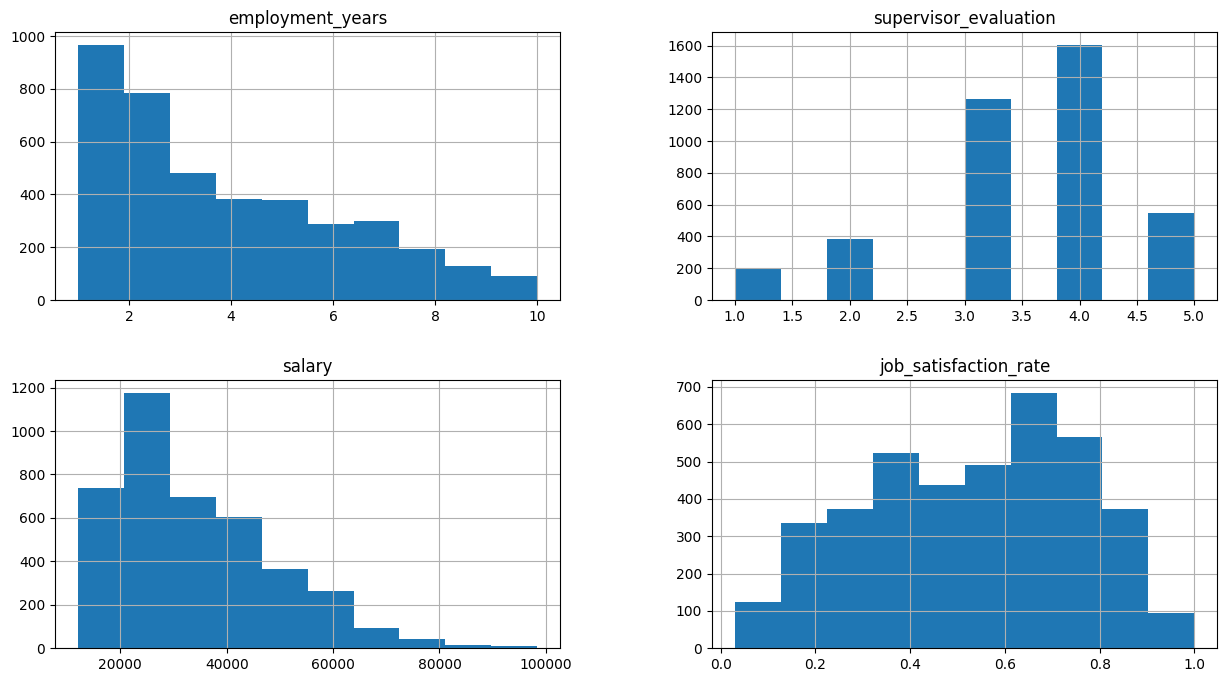

In [4]:
general_information(train_job_satisfaction) 

В датасете можем сразу приметить наличие пропусков, все столбцы имеют должный тип, всего строк 4000 
* Рабочий стаж имеет значения в диапазоне от 1 до 10, медианный стаж 3-4 года, значит встретить сотрудника с возврастом более 4 лет менее вероятно чем у которого от 1 до 3 лет, чем больше стаж тем меньше кол-во сотрудников
* Оценка качества работу сотрудника оценивается по шкатле от 1 до 5, распределение оценки близко к нормальому, имеет смещение вправо. 
* Зарплата сотрудников лежит в диапазоне значений от 12_000 до почти 100_000 в среднем сотрудники компании получают около 30_000, распределение значений близко к нормальному, но имеет сильное смещение влево
* Показатель удовлетворённости имеет значения в интервале от 0,03 до 1, Распределение похоже на нормальное
* Всего депортаментов 5, самый популярный это отдел продаж
* Всего уровней должности 3 самые популярные в датасете это стажёры
* Интенсивностей нагрузки различают 3, средняя самая распрастраннёная
* Практически все сотрудники не получали повышение зарплат
* Почти 15% всех сотрудников из датасета нарушали трудовой договор

### Второй датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.2135,253851.326129,100298.0,339052.0,550793.0,765763.75,999029.0
employment_years,2000.0,3.6665,2.537222,1.0,1.0,3.0,6.00,10.0
supervisor_evaluation,2000.0,3.5265,0.996892,1.0,3.0,4.0,4.00,5.0
salary,2000.0,34066.8000,15398.436729,12000.0,22800.0,30000.0,43200.00,96000.0


,dept,level,workload,last_year_promo,last_year_violations
count,1998,1999,2000,2000,2000
unique,6,3,4,2,2
top,sales,junior,medium,no,no
freq,763,974,1043,1937,1738


array([[<Axes: title={'center': 'employment_years'}>,
        <Axes: title={'center': 'supervisor_evaluation'}>],
       [<Axes: title={'center': 'salary'}>, <Axes: >]], dtype=object)

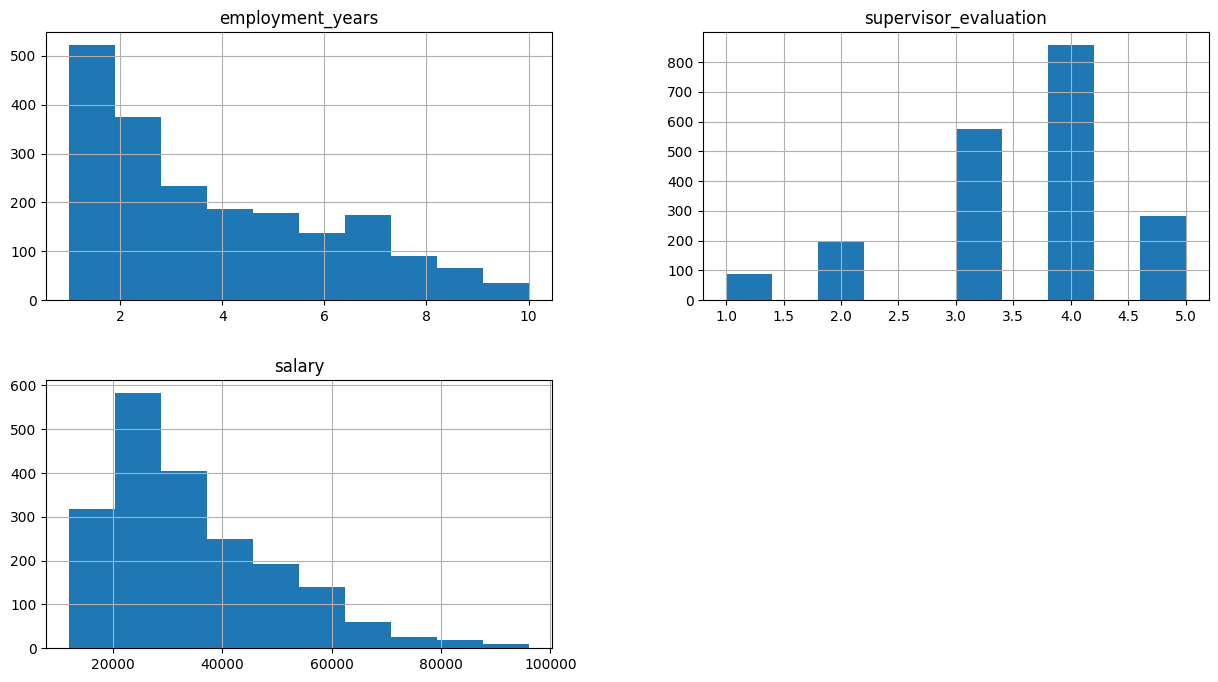

In [5]:
general_information(test_features) 

Описание признаков второго датасета, аналогичное первого датасета

### Посмотрим на третий датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


None

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.21350,253851.326129,100298.00,339052.00,550793.00,765763.75,999029.0
job_satisfaction_rate,2000.0,0.54878,0.220110,0.03,0.38,0.58,0.72,1.0


array([[<Axes: title={'center': 'job_satisfaction_rate'}>]], dtype=object)

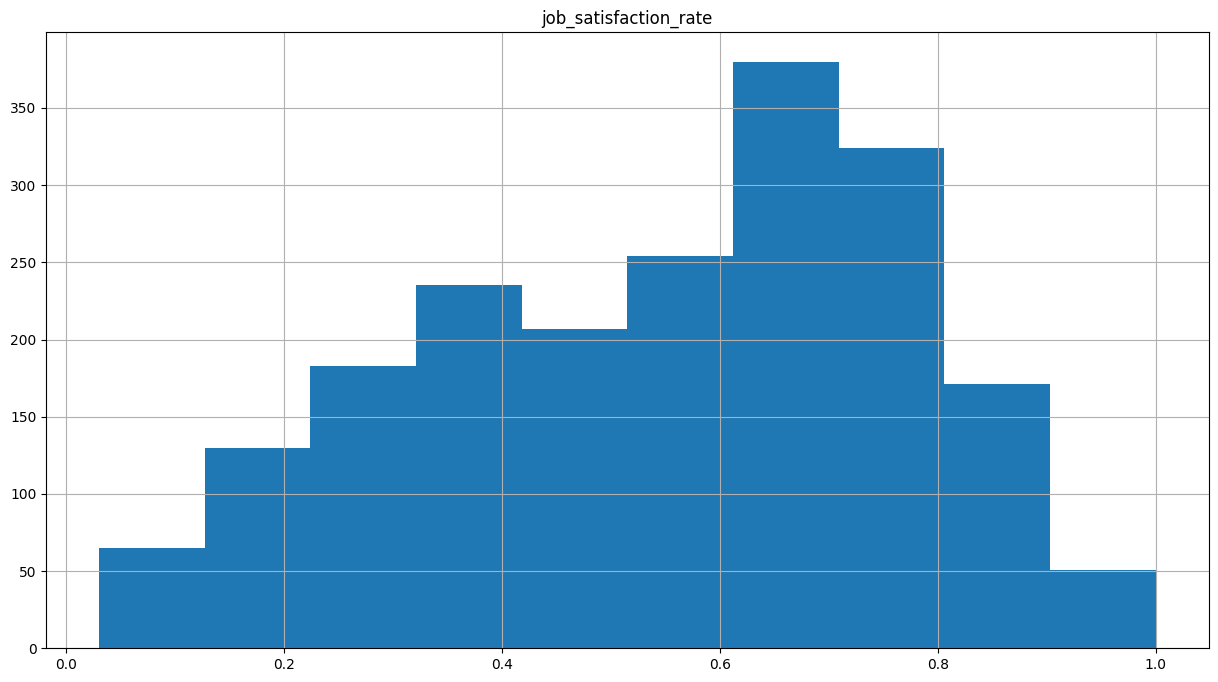

In [6]:
general_information(test_target_job_satisfaction) 

Аналогично таргету из первого датасета

### Общий вывод

Все данные реалистичны, есть категориальные и числовые столбцы, данные преимущественно распределяются нормально, в первых двух датасетах есть пропуски. 

## Предобработка данных

Посмотрим на наши пропуски

In [7]:
display(train_job_satisfaction.loc[train_job_satisfaction['dept'].isna()])
display(test_features.loc[test_features['dept'].isna()])
display(train_job_satisfaction.loc[train_job_satisfaction['level'].isna()])
display(test_features.loc[test_features['level'].isna()])


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
191,609865,NaN,junior,medium,1,no,no,1,20400
1196,832342,NaN,junior,medium,1,no,no,4,28800


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
312,471990,sales,NaN,low,1,no,no,3,12000


In [8]:
test_features['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
      dtype=object)

Можем заметить пропуск ввиде пробела, посмотрим на ту строку


In [9]:
test_features[test_features['dept'] == ' ']

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
1699,822186,,middle,medium,3,no,no,4,38400


In [10]:
test_features[test_features['dept'] == ' '] = np.nan

Видим, что в каждой строке только по одному пропуску на все признаки

Проверим на наличие дубликатов


In [11]:
print(train_job_satisfaction.duplicated().sum())
print(test_features.duplicated().sum())
print(test_target_job_satisfaction.duplicated().sum())

0
0
0


Дубликатов не обнаруженно! Проверим не явные дубликаты по id, есть вероятность, что один id может дважды учасвствовать в опросе

In [12]:
print(train_job_satisfaction['id'].duplicated().sum())
print(test_features['id'].duplicated().sum())
print(test_target_job_satisfaction['id'].duplicated().sum())

0
0
0


Всё отлично!

Проверим на наличие дубликатов, не по id, предварительно соединим два датасета с тестовой выборки

In [13]:
merge = pd.merge(test_features, test_target_job_satisfaction, on='id')
print(train_job_satisfaction.iloc[:, 1:].duplicated().sum())
print(merge.iloc[:, 1:].duplicated().sum())

245
83


Очень интересный вывод, в данных очень много неявных дубликатов, следует уточнить о кол-ве сотрудников которое находится в штате\которое учавствовало в опросе и маниторинге, ведь многие столбцы являются реалистичными, и не получится разграничить дубликат от случайного совпадения

In [14]:
row = train_job_satisfaction[train_job_satisfaction.iloc[:, 1:].duplicated()]
wor = merge[merge.iloc[:, 1:].duplicated()]

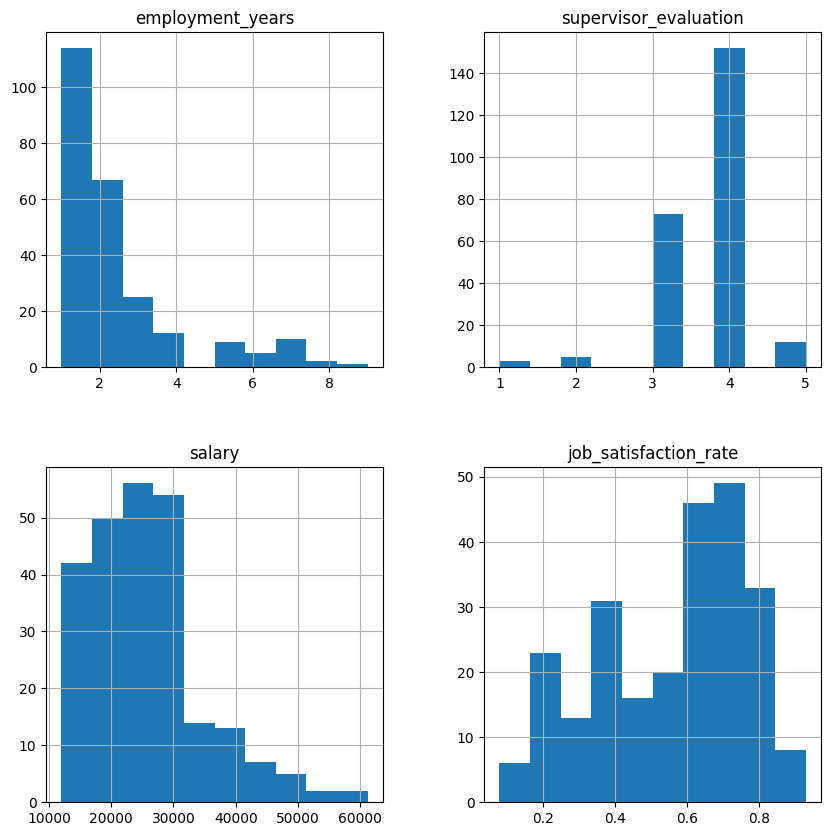

In [15]:
row.iloc[:, 1:].hist(figsize=(10,10));

Пока что не удалим полные дубликаты из выборок до выяснения обстоятельств, так как в дальнейшем это может повлиять на веса моделей при обучении и на качество метрики

In [16]:
#train_job_satisfaction = train_job_satisfaction.drop(row.index, axis=0)
#test_features = test_features.drop(wor.index, axis=0)
#test_target_job_satisfaction = test_target_job_satisfaction.drop(wor.index, axis=0)

### Итог предобработки
Данные находятся в почти идиальном состоянии, единственное что их портит это наличие пропусков, заполним их вдальнейшем с помощью пайплайна, что касается дубликатов, этот момент стоит уточнить у заказчика

## Исследовательский анализ данных

### Исследуем числовые столбцы первого датасета 

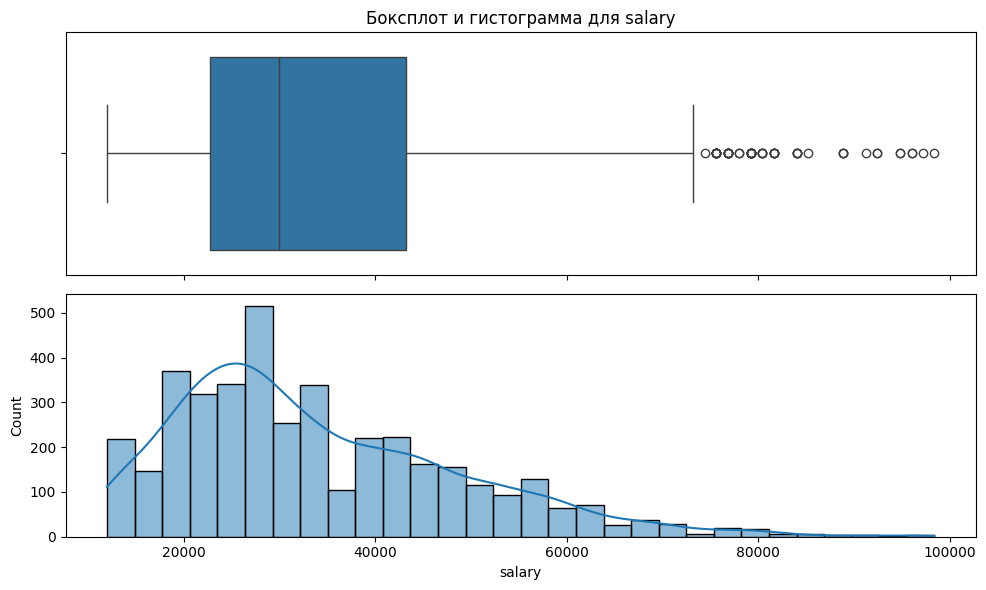

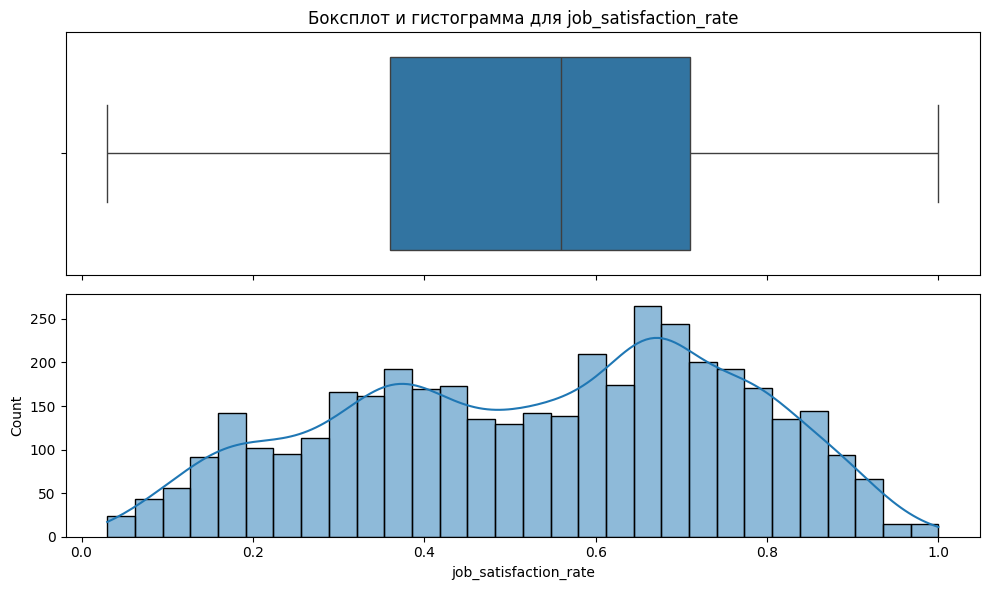

In [17]:
columns = ['salary', 'job_satisfaction_rate']
def px_box(data, column):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 6))
    sns.boxplot(data=data, x=column, ax=ax_box)
    sns.histplot(data[column], ax=ax_hist, bins=30, kde=True)
    ax_box.set_title(f'Боксплот и гистограмма для {column}')
    ax_box.set(xlabel='')
    ax_hist.set(xlabel=column)
    plt.tight_layout()
    plt.show()
for column in columns:
    px_box(train_job_satisfaction, column)

Можем заметить:
* Стаж сотрудников начинается с 1 года до 10 лет, причё чем больше стаж, тем меньше вероятность встреть такого человека, выбрасов не обнаруженно
* Оценка руководителя подразделения оценивается по пятибольной шкале, где 5 - это отлично. Больше всего сотрудников имеют заслуженную 4ку. Есть некоторое количество выбрасов, но жто не так, это редкий случай когда сотрудники плохо работают
* Зарплата сотрудников варьируется от 15т до 100т, медиана по зарплате 22-25т, есть выбросы, но это скорее зарплаты руководителей подразделений
* Показатель удовлетворённости работой варьируется от 0 до 1, где 1 это супер, медиана этого показателя-0,65-0,7
У всех столбцов, кроме первого, распределение близкое к нормальному, выбрасы есть, но это частный случай


### Исследуем категориальные признаки первого датасета

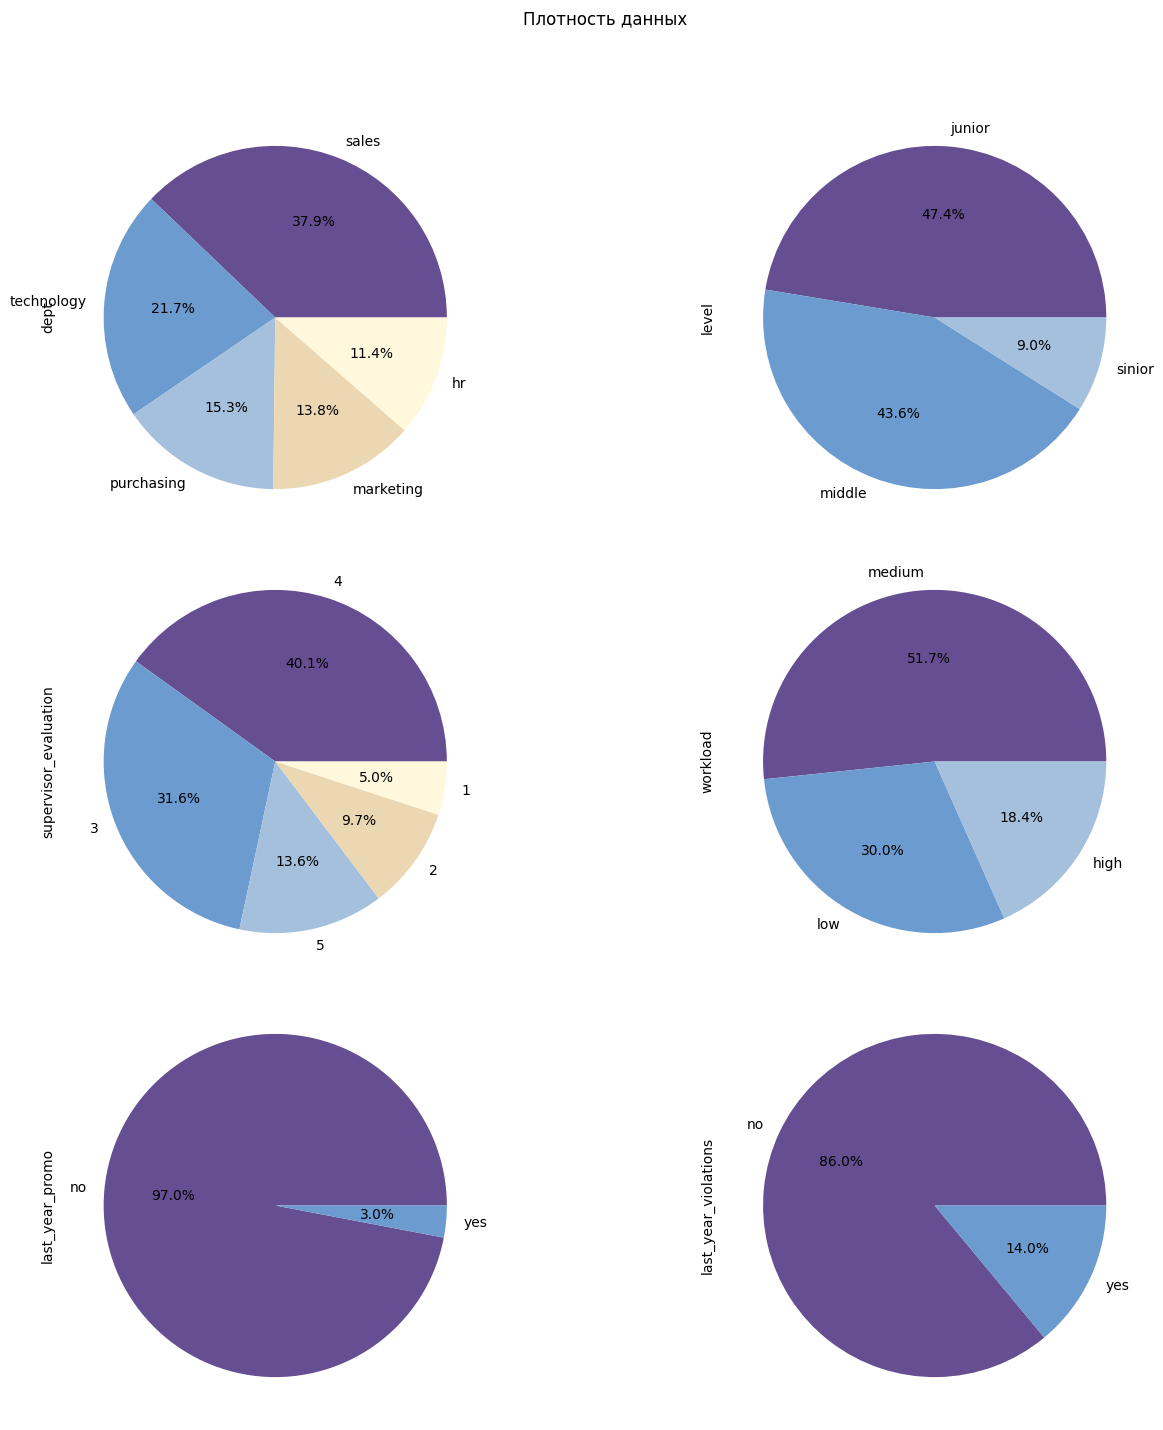

In [18]:
columns = ['dept', 'level', 'supervisor_evaluation',
       'workload', 'last_year_promo', 'last_year_violations']
pastel_colors = ['#654E92', '#6C9BCF', '#A5C0DD', '#EBD8B2', '#FFF8DC', '#1C86EE']

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Плотность данных')
axs = axs.flatten()

for i, column in enumerate(columns):
    train_job_satisfaction[column].value_counts().plot(kind='pie', ax=axs[i], colors=pastel_colors, autopct='%1.1f%%')
    axs[i].set_ylabel(column)  
#fig.delaxes(axs[-1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

В ходе анализа выяснили, что:
- Больше всего сотрудников в отделе продаж, а меньше всего в отделе hr
- Самый распрастранённый уровень у сотрудников это джуниор и мидл, сеньёр всего 9%
- Чуть больше половины сотрудников имеют среднюю нагрузку, низкую нагрузку имеют 30% сотрудников
- Повышение заработной платы было лишь у 3% сотрудников
- У 14% сотрудников были выявленны нарушения с трудовым договором

для визуализации признака 'supervisor_evaluation', построим barplot, так как он содержит более 6 уникальных значений

<Axes: xlabel='employment_years'>

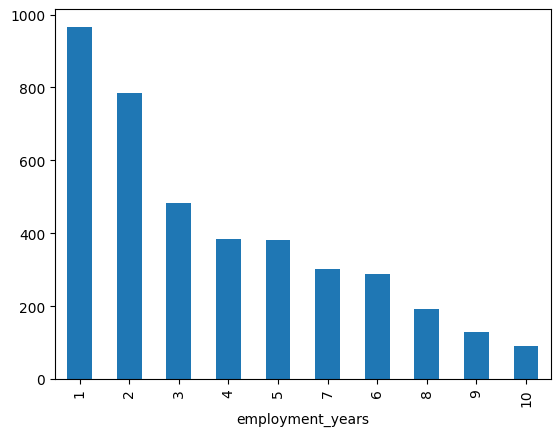

In [19]:
train_job_satisfaction['employment_years'].value_counts().plot(kind='bar')

Стаж сотрудников начинается с 1 года до 10 лет, причё чем больше стаж, тем меньше вероятность встреть такого человека

### Исследуем числовые столбцы второго датасета

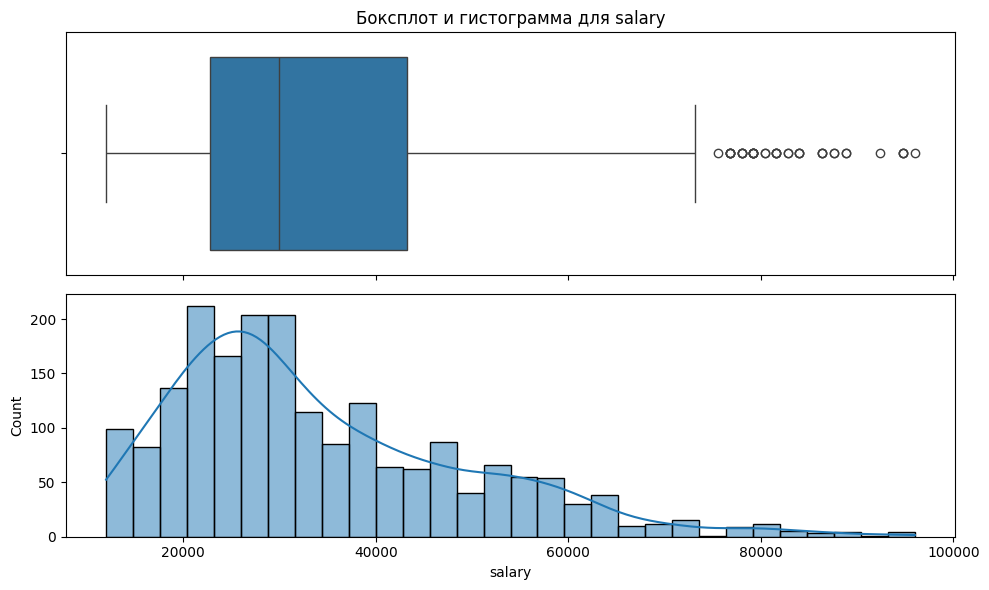

In [20]:
px_box(test_features, 'salary')

Выводы аналогичны тем что были выявленны в первом датасете

### Исследуем категориальные признаки первого датасета

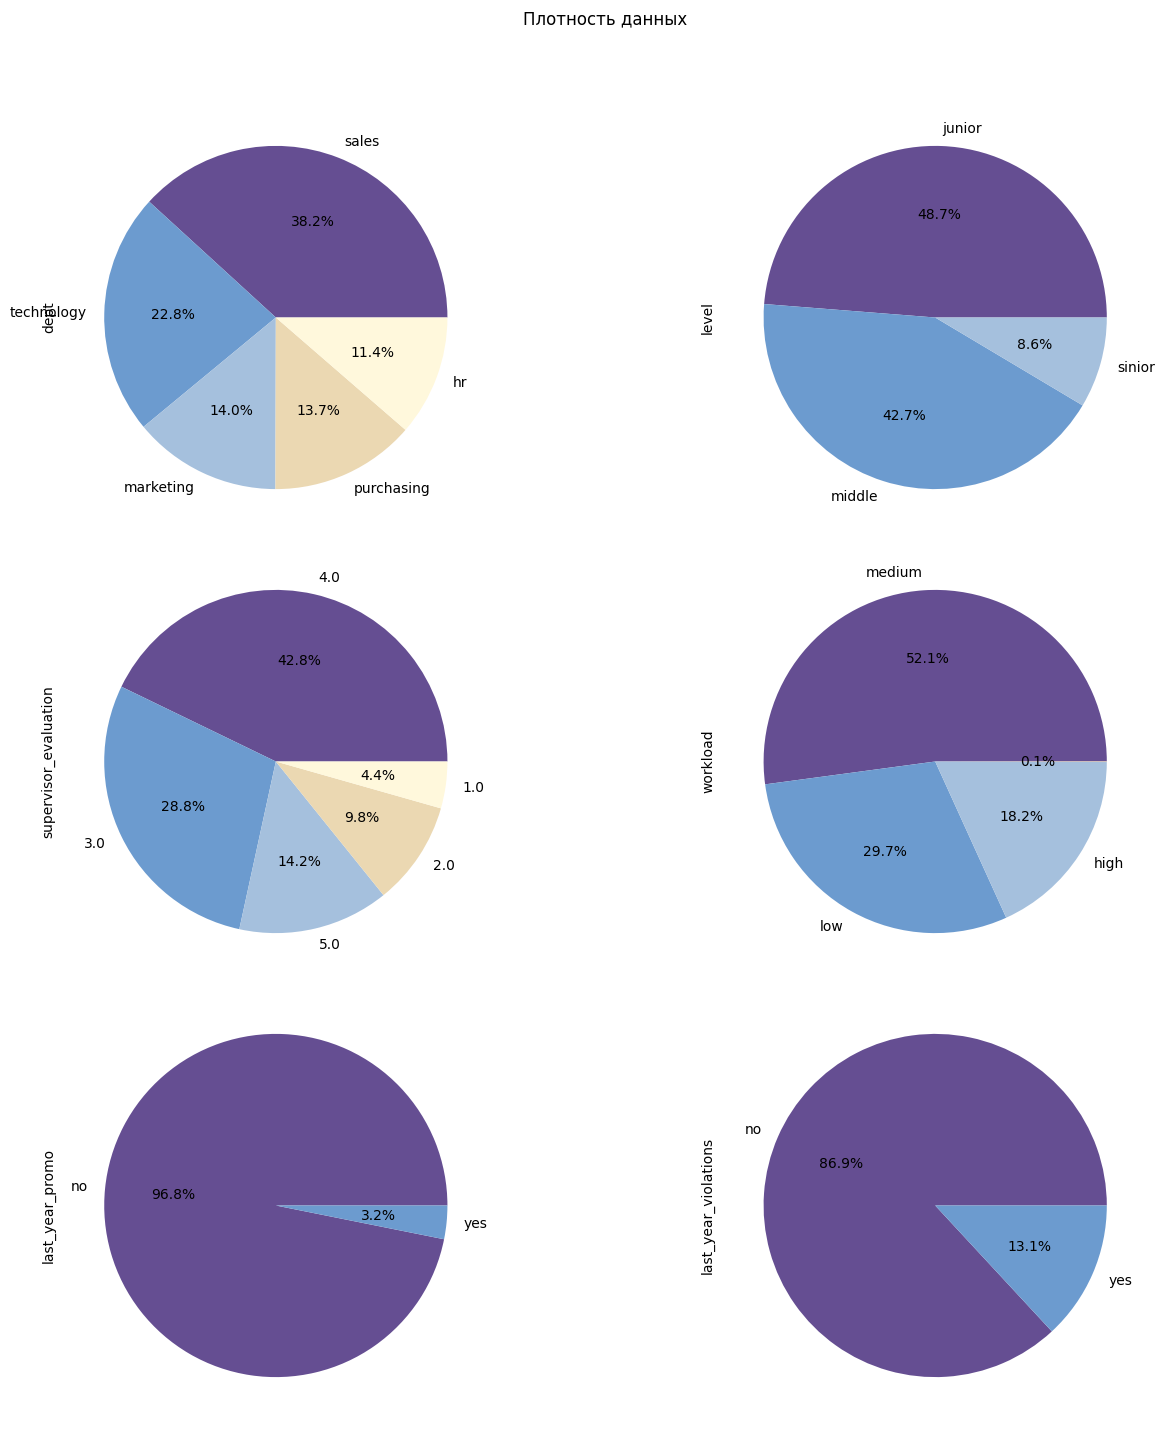

In [21]:
columns = ['dept', 'level', 'supervisor_evaluation',
       'workload', 'last_year_promo', 'last_year_violations']
pastel_colors = ['#654E92', '#6C9BCF', '#A5C0DD', '#EBD8B2', '#FFF8DC', '#1C86EE']

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Плотность данных')
axs = axs.flatten()

for i, column in enumerate(columns):
    test_features[column].value_counts().plot(kind='pie', ax=axs[i], colors=pastel_colors, autopct='%1.1f%%')
    axs[i].set_ylabel(column)  
#fig.delaxes(axs[-1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

<Axes: xlabel='employment_years'>

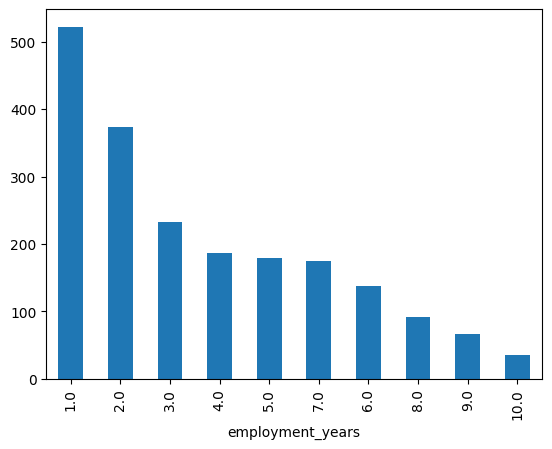

In [22]:
test_features['employment_years'].value_counts().plot(kind='bar')

Аналогичная ситуация, можем константировать воспроизводимость выборок

### Исследуем третий датасет

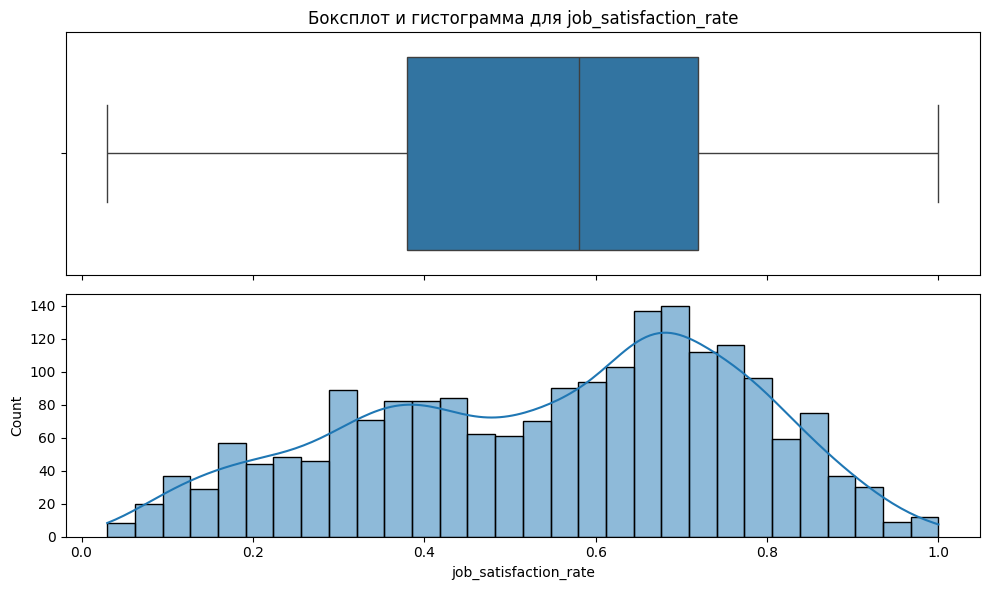

In [23]:
px_box(test_target_job_satisfaction, 'job_satisfaction_rate')

Тут мы тоже можем константировать, что выборка воспроизводимая

### Проведём корреляционный анализ

Оставим признак id чтоб понаблюдать за его корреляцией, если она проявится, это может сведетельствовать о том,что признак, с которым он коррелирует, имеет сильные шумы и искажает результат обучения

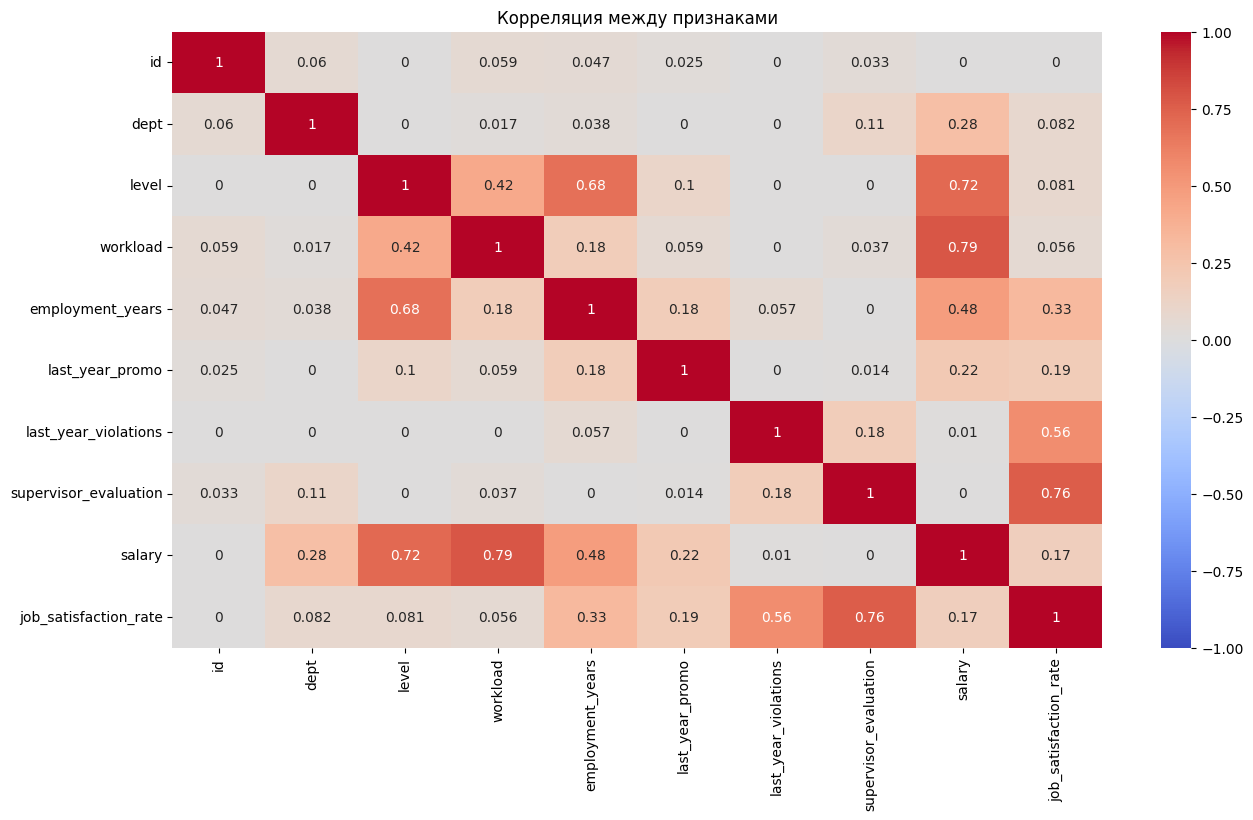

In [24]:
df_phik_matrix = train_job_satisfaction.phik_matrix(interval_cols = ['id', 'salary', 'job_satisfaction_rate'])
plt.figure(figsize=(15, 8))
sns.heatmap(df_phik_matrix, annot=True, cmap='coolwarm', vmin=-1)
plt.title('Корреляция между признаками')
plt.show()

Можем заметить, что такие признаки как уровень и заработная плата имеет сильную корреляцию с множеством других столбцов, посмотрим на наличие мультиколлениарности

In [25]:

#for i in range(len(train_job_satisfaction.columns)):
#    for j in range(i + 1, len(train_job_satisfaction.columns)):
#        if abs(train_job_satisfaction.phik_matrix().iloc[i, j]) > 0.7:
#            print(f"Признаки '{train_job_satisfaction.columns[i]}' и '{train_job_satisfaction.columns[j]}' могут быть мультиколлинеарны.")

Краткая выжимка из результата

`Признаки 'level' и 'salary' могут быть мультиколлинеарны.
Признаки 'workload' и 'salary' могут быть мультиколлинеарны.
Признаки 'supervisor_evaluation' и 'job_satisfaction_rate' могут быть мультиколлинеарны.`

Посмотрим на паирплот для оценки взаимодействия признаков

In [26]:
df = train_job_satisfaction.dropna()

conditions = [
    df['job_satisfaction_rate'] < 0.3,
    (df['job_satisfaction_rate'] >= 0.3) & (df['job_satisfaction_rate'] <= 0.7),
    df['job_satisfaction_rate'] > 0.7
]

choices = [
    'низкая лояльность', 
    'средняя лояльность',  
    'высокая лояльность'  
]
df['loyalty'] = np.select(conditions, choices, default='неизвестно')



ordered_cols = [
    'level', 'workload', 'last_year_promo', 'last_year_violations'
]

encoder = OrdinalEncoder(handle_unknown='use_encoded_value',
    categories=[
        ['junior', 'middle', 'sinior'],
        ['low', 'medium', 'high'],
        ['no', 'yes'],
        ['no', 'yes']],
    unknown_value=np.nan)
df[ordered_cols] = encoder.fit_transform(df[ordered_cols])

display(df.head(2))

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,loyalty
0,155278,sales,0.0,1.0,2,0.0,0.0,1,24000,0.58,средняя лояльность
1,653870,hr,0.0,2.0,2,0.0,0.0,5,38400,0.76,высокая лояльность


<Figure size 1000x1000 with 0 Axes>

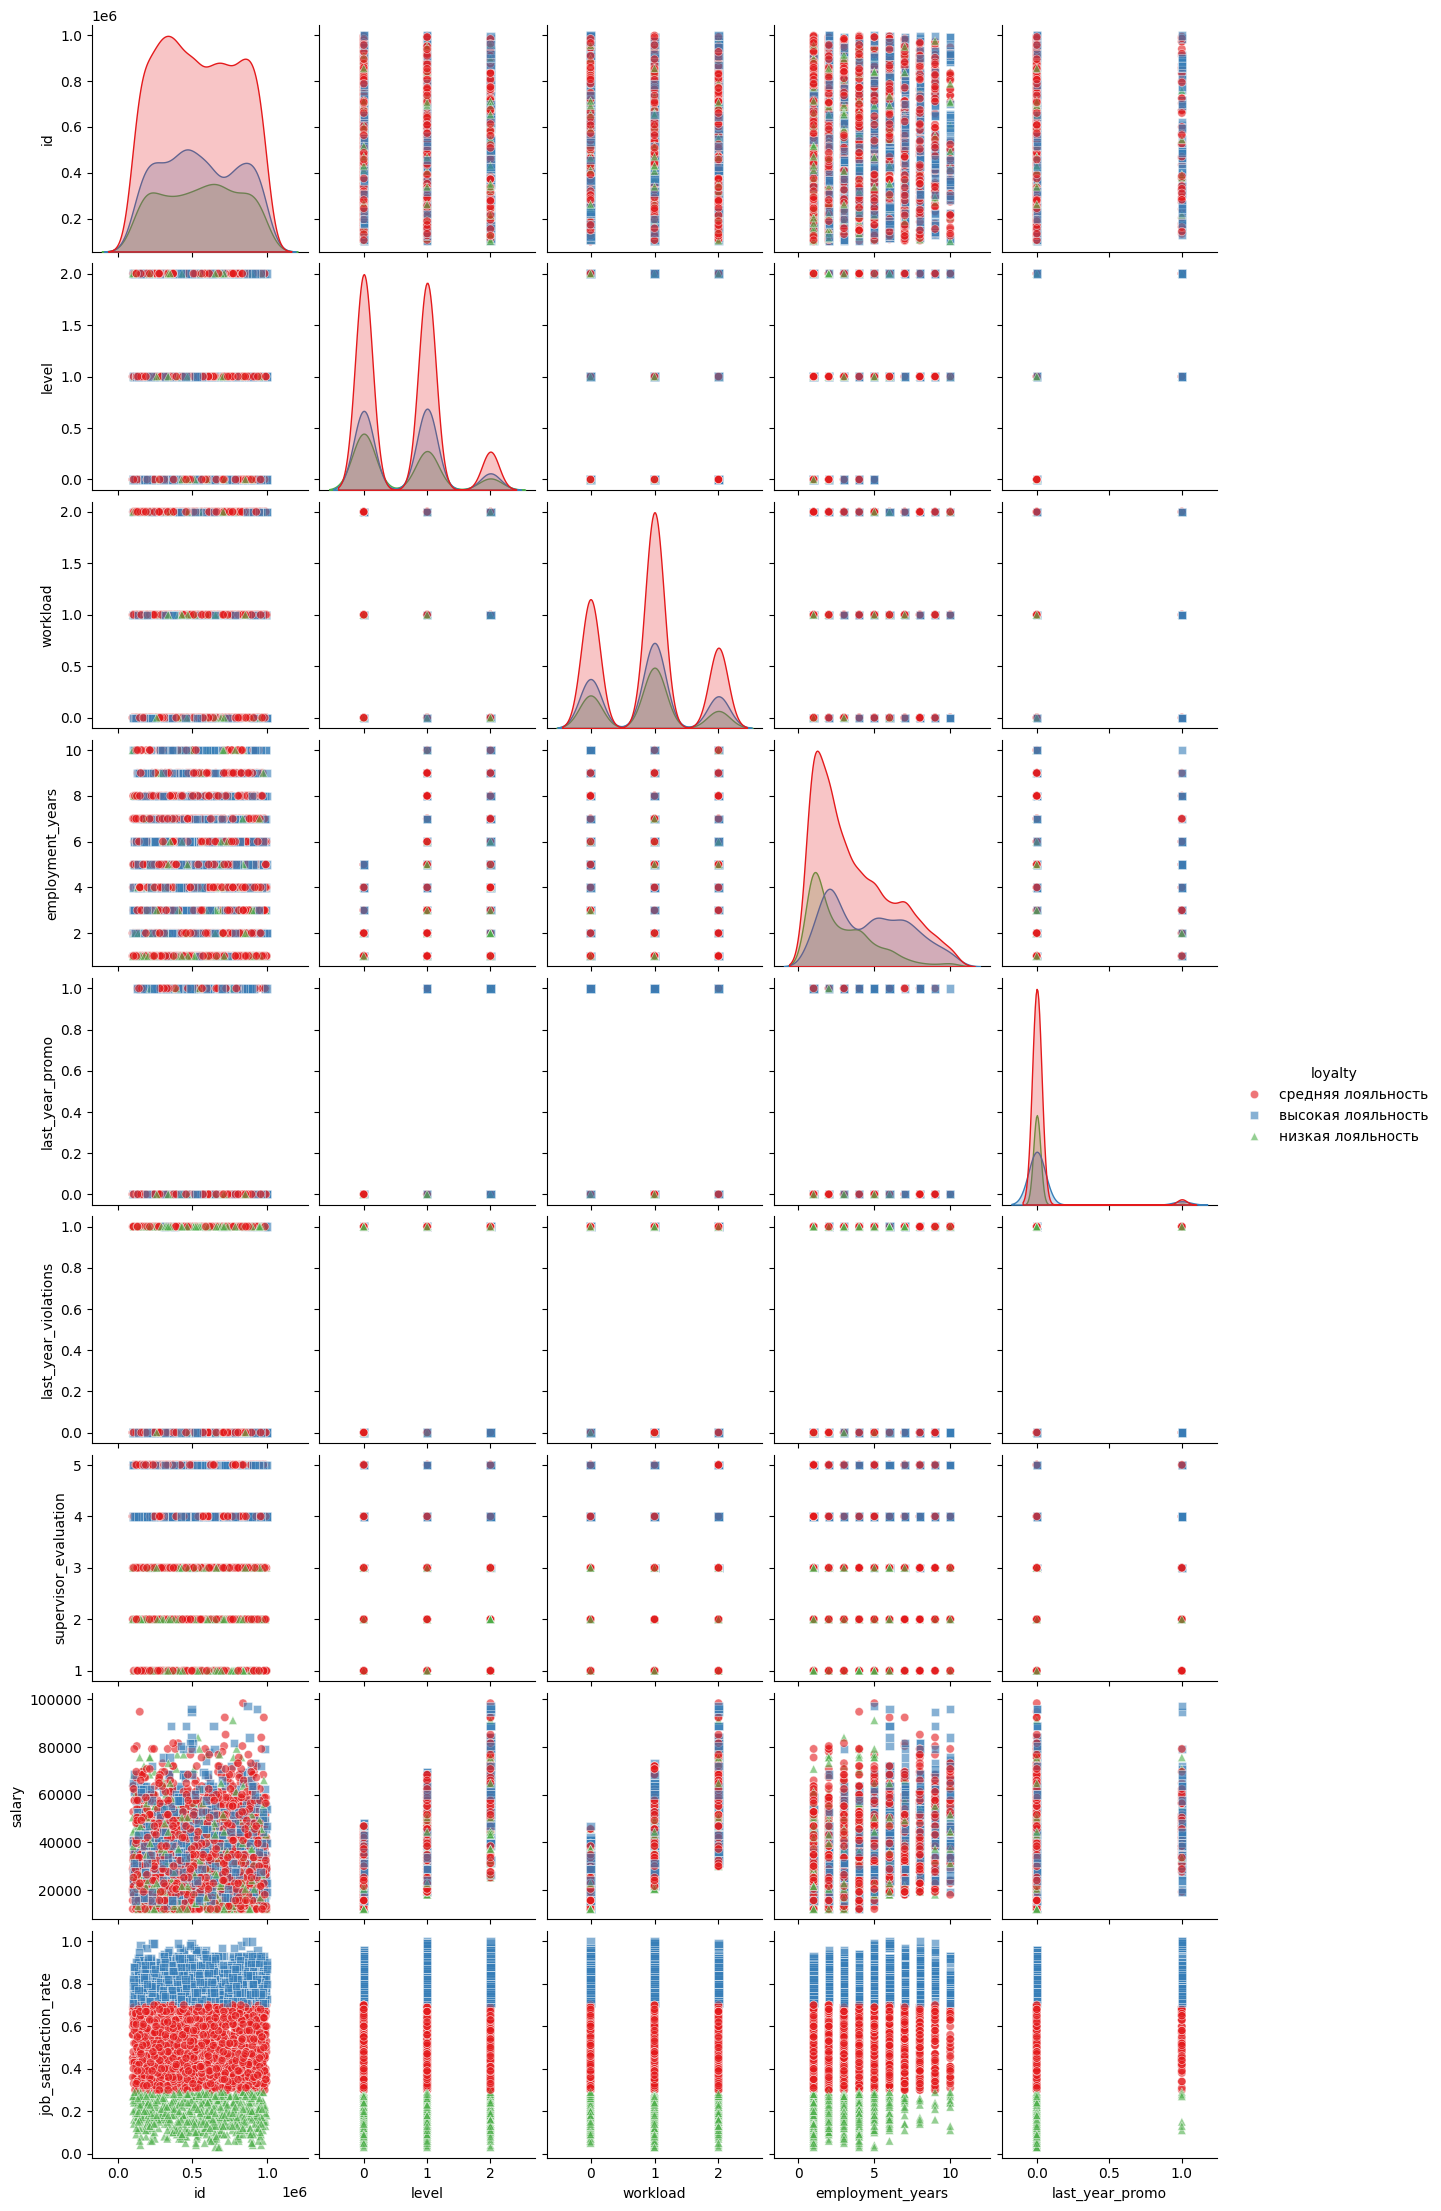

<Figure size 1000x1000 with 0 Axes>

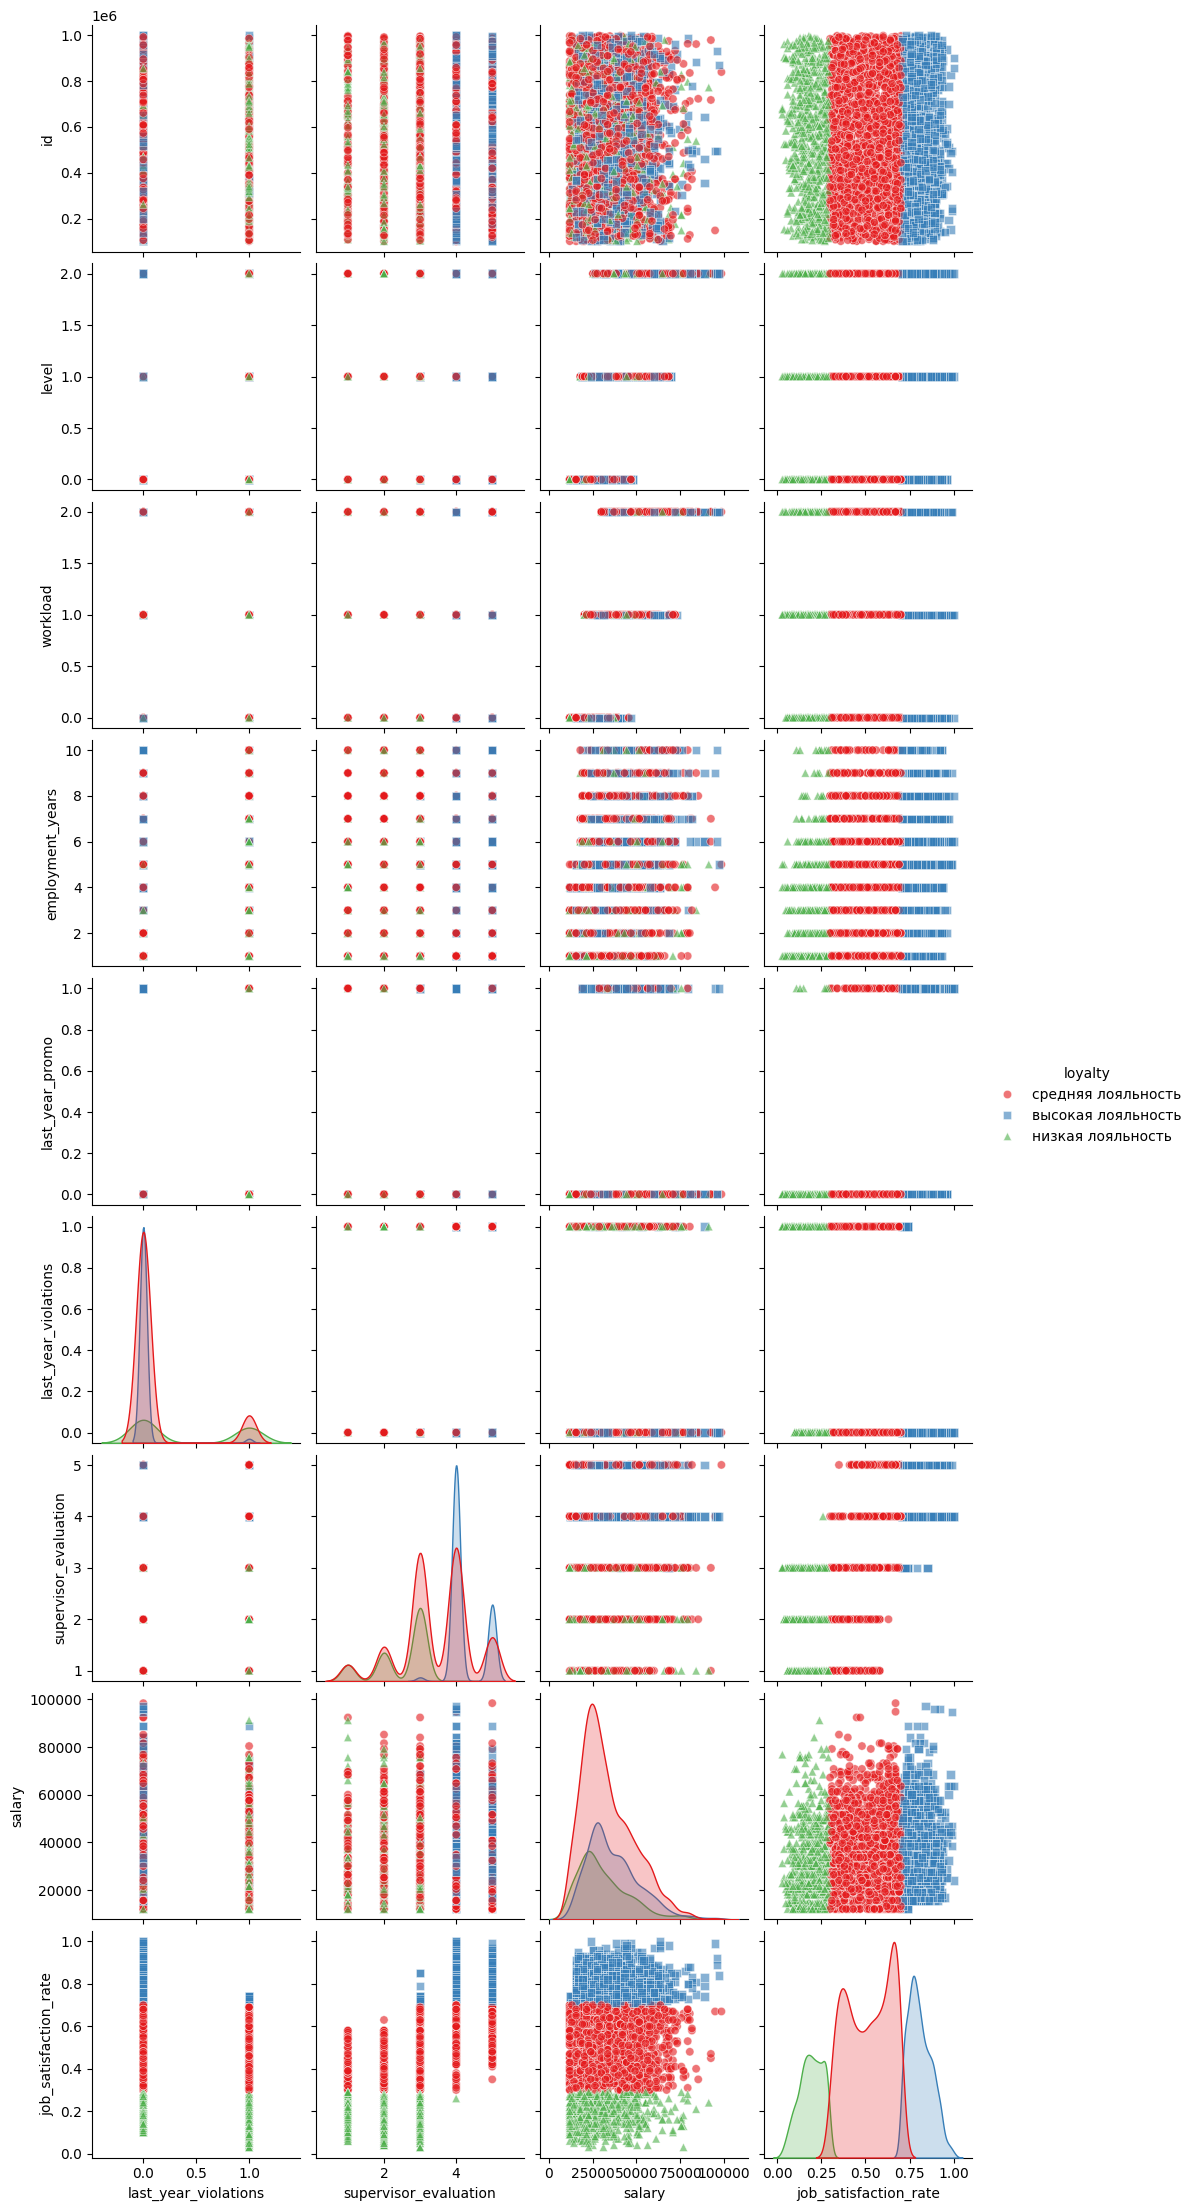

In [27]:
numeric_columns = list(df.select_dtypes(include='number').columns)
x = numeric_columns[:5]
x1 = numeric_columns[5:]
x_x = x, x1

for i in x_x:
    plt.figure(figsize=(10, 10))
    sns.pairplot(df, kind="scatter", hue="loyalty", markers=["o", "s", "^"], palette="Set1",
            x_vars=i,
            y_vars=numeric_columns,
            plot_kws={'alpha': 0.6})
plt.show()

Выводы:
- для признака Уровень профессионализма:
** при уровне джуниор и при любой загруженности сотрудники преимущественно имеют среднюю лояльность, вероятно это связанно с неопытностью в данной сфере или связанно с адаптацией к этой компании, сотрудник не может рационально оценить, что из его работы имеет смысл быть, а что из ряда вон
** при уровне мидл при слабой нагрузке имеют высокую лояльность, очевидный человеческий фактор
** при мидл и высокой нагрузке 50/50 средней и высокой лояльности, в этом подразделе можно выделить ссотрудников которые очень любят свою работу/компанию и имеют высокий КПД, при средней нагрузке, лояльность сбалансированна в примерно равных долях
** так же есть только джуниоры которые не получали повышение зп, возможно это связанно с возможным наличием стажировок или если например при повышении зарпталы сотрудника переводят на следующий уровень
** для мидл, как только сотрудники получали повышение, стали иметь высокую лояльность, явный человеческий фактор
все сеньёры по большей степени имеют высокую лояльность в независимости от повышения, это связанно с тем что до этого уровня доходит далеко не каждый сотрудник, а доходят только те кто действительно любит эту работу и проявляет высокий уровень своей компитенции
- для признака Уровень загруженности:
** При повышении заработной платы сотрудники всех видов загруженности имеют высокую лояльность, Человеческий фактор
** При средней загруженности и отсутствии повышения заработной платы, сотрудники имеют преимущественно низкую лояльность, а при высокой нагруженности и отсутвии повышение преимущественно среднюю лояльность, это можно обьяснить так, при средней загруженности сотрудники могут сравнивать свою работу с работой других и видеть, что они не получают достаточной компенсации за свои усилия, что снижает их лояльность. При высокой загруженности они могут чувствовать, что их усилия более значимы, даже если они не получают за это материального вознаграждения или же сотрудники, работающие в условиях высокой нагрузки, могут чувствовать большую ответственность за свою работу и команду, что может способствовать формированию определенной лояльности. Однако эта лояльность может быть неустойчивой и зависеть от общей атмосферы в коллективе и уровня стресса.
- для признака наличия нарушений:
** сотрудники у которых были выявленны нарушения, с большим преимуществом имеют низкую лояльность и среднюю лояльность (тут можно разделить сотрудников с средней лояльностью на ответственных и не ответственных), человеческий фактор
** сотрудники у которых нарушений не выявленно, с большим преимуществом имеют высоку лояльность и среднюю лояльность (тут как раз ответственные сотрудники с средней лояльностью)
- для признака оценка от руководителя:
** руководитель равномерно и непредвзято оценивает все возрасты
** чем выше оценка руководителя, тем выше лояльность, человеческий фактор
- для признака заработная плата:
** чем выше уровень профессионализма и выше загруженность сотрудника тем выше смещается интервал зарплат
- для признака повышения з\п:
** тот факт что произошло повышение заработной платы, увеличивает лояльность сотрудников

Но посмотрим на паирплот для тех призаков, которые проявили мультиколлинеарность, но график уже будет с регрессионной линией

<Figure size 500x500 with 0 Axes>

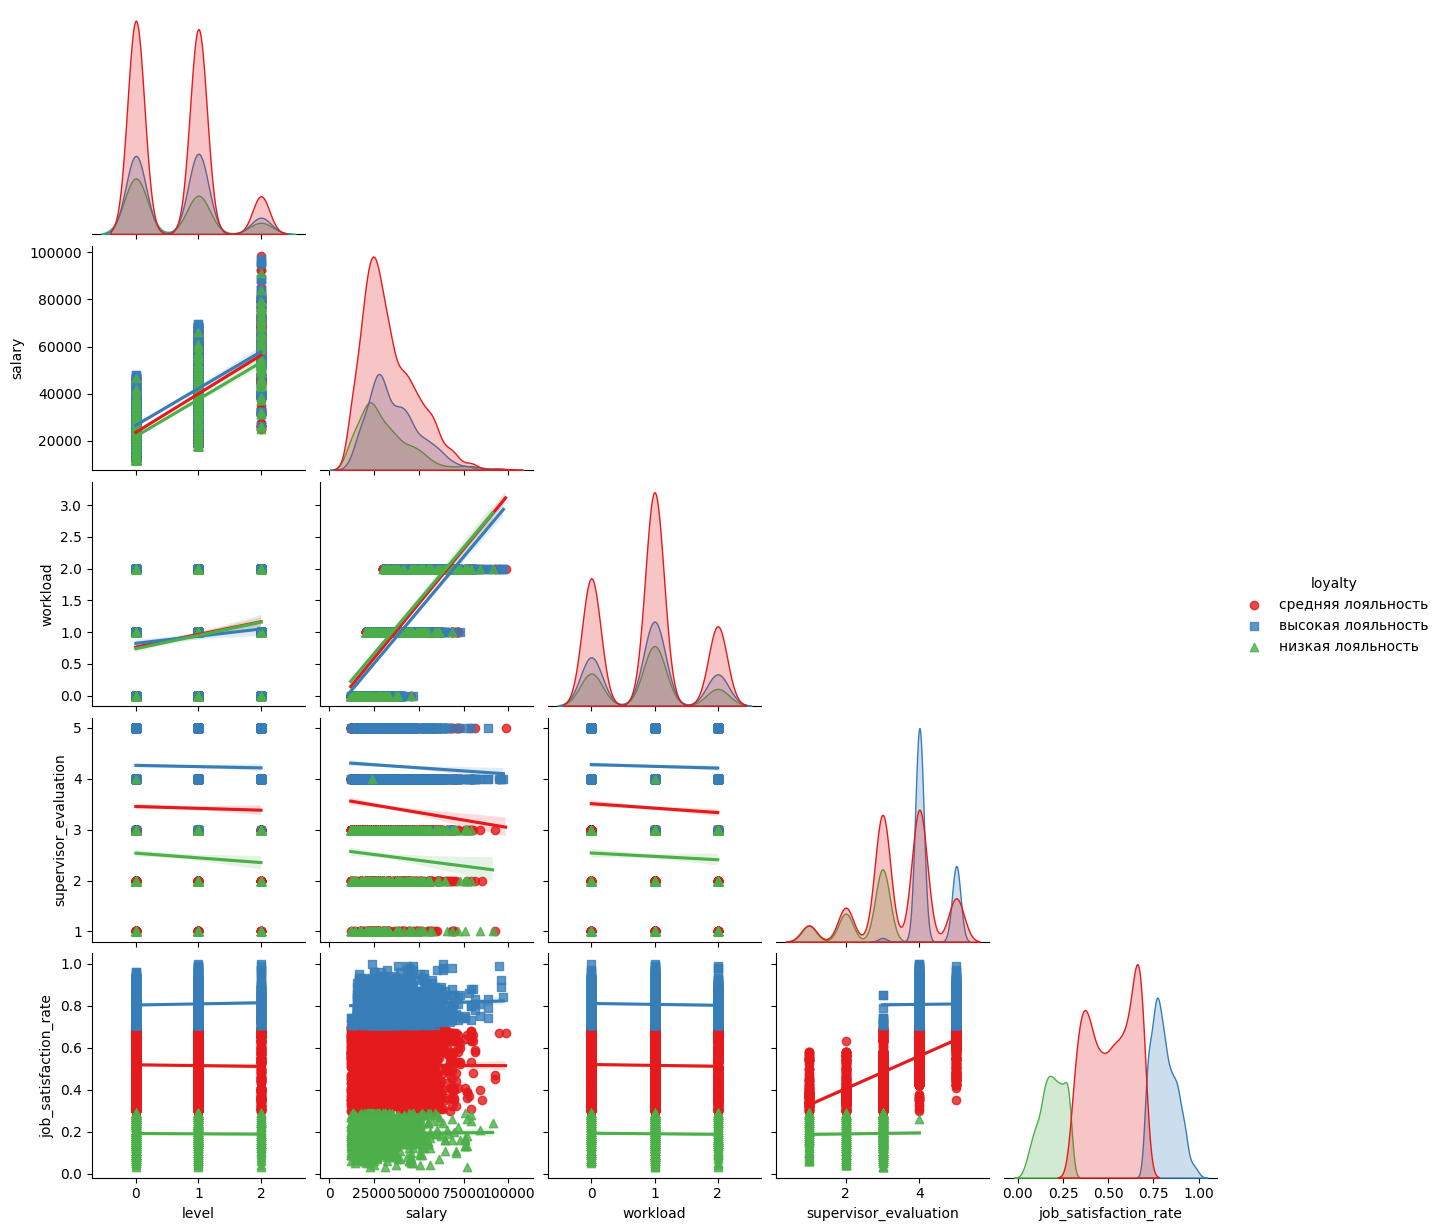

In [28]:
col = ['level', 'salary', 'workload', 'supervisor_evaluation', 'job_satisfaction_rate', 'loyalty']
df = df[col]
plt.figure(figsize=(5, 5))
sns.pairplot(df, hue="loyalty", markers=["o", "s", "^"], palette="Set1", kind='reg', corner=True)

Интересные факти при анализе:
- Для признака заработная плата, можем увидеть, что при повышении уровня профессионализма и рабочей нагрузки вместе с ними растёт и заработная плата
- Для признаков оценка руководителя и уровень лояльности, замечен интересный факт, если для низкого и высокого уроврня лояльности, оценка руководителя влияет не сильно, то для среднего уровня лояльности он проявляет своё максимальное взаимодействие на этот признак, это взаимодействие более вырозительно из-за того что средняя лояльность это мажорный класс признака

## Обучение и подбор моделей

Для начала выделим столбцы с определёнными типами, категориальные числовые дискретные и числовые ранговые

In [29]:
ohe_columns = ['dept']
ord_columns = ['level', 'workload', 'last_year_promo', 'last_year_violations']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']

Теперь разделим и определим все выборки как обучающие целевые и признаковые, а так же тестовые признаковые и целевые

In [30]:
X_train = train_job_satisfaction.drop(['id', 'job_satisfaction_rate'], axis=1)
y_train = train_job_satisfaction['job_satisfaction_rate']
X_test = test_features
y_test = test_target_job_satisfaction
merged = pd.merge(y_test, X_test, on='id')
merged = merged.sort_values(by='id')
X_test = merged.drop(['id', 'job_satisfaction_rate'], axis=1)
y_test = merged['job_satisfaction_rate']

Соберём несколько пайплайнов и совместим их затем в один

In [32]:
ohe_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False)),
    ('simpleImputer_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        categories=[
            ['junior', 'middle', 'sinior'], 
            ['low', 'medium', 'high'],
            ['no', 'yes'],
            ['no', 'yes']], 
        handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, ohe_columns),  
        ('ord', ord_pipe, ord_columns),    
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', RandomForestRegressor(random_state=RANDOM_STATE))])
param_grid = [
    {
        'models': [RandomForestRegressor(random_state=42)],
        'models__max_depth': range(2, 3),
        'models__max_features': range(2, len(num_columns) + 1),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [KNeighborsRegressor()],
        'models__n_neighbors': range(2, 4),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [SVR()],
        'models__C': range(1, 5),
        'models__kernel': ['linear', 'poly', 'rbf'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    }
]        
def custom_metric(y_test, y_pred):
    error = np.abs(y_test - y_pred)
    scale = (np.abs(y_test) + np.abs(y_pred)) / 2
    return np.mean(error / scale) * 100
scorer = make_scorer(custom_metric, greater_is_better=False)    
grid_searchCV = GridSearchCV(
    pipe_final,
    param_grid,
    cv=5,
    scoring=scorer,  
    n_jobs=-1,
    error_score = 'raise'
)

Пайплайн готов, проведём кросс-валидацию и найдём лучшую модель и её гиперпараметры

In [33]:
grid_searchCV.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_before_ord',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        sparse_output=False)),
                                                                                         ('simpleImputer_after_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')...
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler()]},
                         {'models': [LinearRegression()],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler()]},
                         {'models': [SVR()], 'models__C': range(1, 5),
                          'models__kernel': ['linear', 'poly', 'rbf'],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler()]}],
             scoring=make_scorer(custom_metric, greater_is_better=False, response_method='predict'))

In [34]:
print('Лучшая модель и её параметры:\n\n', grid_searchCV.best_estimator_)
print ('Метрика лучшей модели на кросс-валидации:', (grid_searchCV.best_score_ *-1))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept']),
                                                 ('ord',
                  

После кросс-валидации мы можем признать самой лучшей моделью SVR(), посмотрим какие ещё модели попали в топ.

In [35]:
result = pd.DataFrame(grid_searchCV.cv_results_)
display(result.sort_values('rank_test_score').head(5)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__max_depth,param_models__max_features,param_preprocessor__num,param_models__n_neighbors,param_models__C,param_models__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
26,0.503599,0.035223,0.135000,0.011576,SVR(),NaN,NaN,StandardScaler(),NaN,3.0,rbf,"{'models': SVR(), 'models__C': 3, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",-14.987041,-14.423877,-14.201342,-15.658695,-14.113509,-14.676893,0.577528,1
32,0.550596,0.024985,0.125400,0.005123,SVR(),NaN,NaN,StandardScaler(),NaN,4.0,rbf,"{'models': SVR(), 'models__C': 4, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",-14.945225,-14.372435,-14.220420,-15.655372,-14.202023,-14.679095,0.557846,2
20,0.419198,0.010246,0.128799,0.002857,SVR(),NaN,NaN,StandardScaler(),NaN,2.0,rbf,"{'models': SVR(), 'models__C': 2, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",-14.954242,-14.509645,-14.198372,-15.689754,-14.196267,-14.709656,0.563098,3
14,0.358399,0.017693,0.139200,0.005418,SVR(),NaN,NaN,StandardScaler(),NaN,1.0,rbf,"{'models': SVR(), 'models__C': 1, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",-14.812667,-14.626077,-14.311524,-15.526785,-14.338931,-14.723197,0.442792,4
6,0.059799,0.006305,0.051812,0.012693,KNeighborsRegressor(),NaN,NaN,StandardScaler(),3.0,NaN,NaN,"{'models': KNeighborsRegressor(), 'models__n_neighbors': 3, 'preprocessor__num': StandardScaler()}",-17.281426,-16.104865,-15.984154,-16.822742,-15.910969,-16.420831,0.539006,5


На втором месте у нас модель KNeighborsRegressor но её метрика нам уже вероятно не подходит

In [36]:
y_pred = grid_searchCV.predict(X_test)
score = custom_metric(np.array(y_test), y_pred)
print('Метрика лучшей модели на тренировочной выборке:', score)

Метрика лучшей модели на тренировочной выборке: 13.5724126324994


Итоговый вывод первой задачи:
Для достойного предсказания, найдена модель, которая предсказывает значение целевого признака такого как удовлетворённость работой у сотрудника, это безусловно важная задача, ведь благодаря этому можно предотвратить отток кадров и избежать их текучки, лучше всего справилась модель SVR c ядром 'rbf', её метрика равняется smape = 13,5 что является отличным показателем

# Перейдём ко второй задаче

## Загрузка новых данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


,count,mean,std,min,25%,50%,75%,max
id,4000.0,552099.28375,260158.031387,100222.0,327785.75,546673.0,781497.75,999915.0
employment_years,4000.0,3.70150,2.541852,1.0,2.00,3.0,6.00,10.0
supervisor_evaluation,4000.0,3.47475,1.004049,1.0,3.00,4.0,4.00,5.0
salary,4000.0,33805.80000,15152.415163,12000.0,22800.00,30000.0,43200.00,96000.0


,dept,level,workload,last_year_promo,last_year_violations,quit
count,4000,4000,4000,4000,4000,4000
unique,5,3,3,2,2,2
top,sales,junior,medium,no,no,no
freq,1438,1949,2118,3887,3455,2872


array([[<AxesSubplot:title={'center':'employment_years'}>,
        <AxesSubplot:title={'center':'supervisor_evaluation'}>],
       [<AxesSubplot:title={'center':'salary'}>, <AxesSubplot:>]],
      dtype=object)

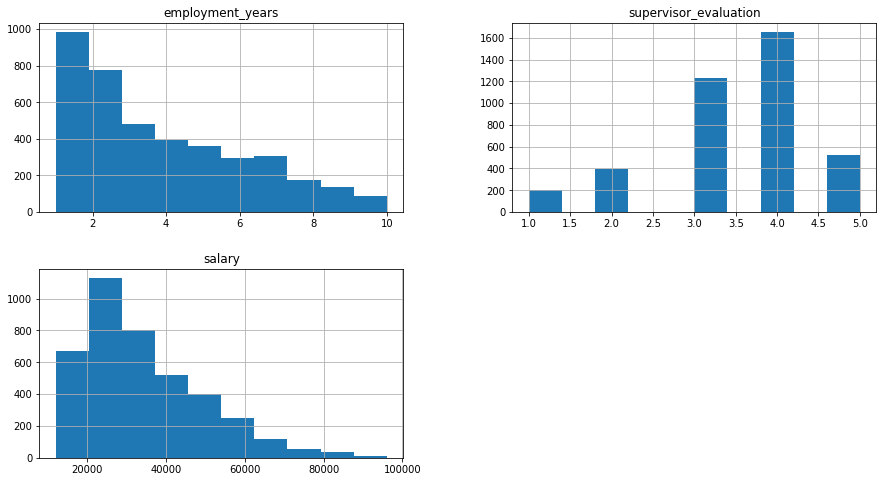

In [37]:
train_quit = pd.read_csv('/datasets/train_quit.csv')
test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
general_information(train_quit)

Пока что мы не можем заметить пропуски, в остальном данные похоже на первый датасет

In [38]:
general_information(test_target_quit)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


None

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


,count,mean,std,min,25%,50%,75%,max
id,2000.0,552765.2135,253851.326129,100298.0,339052.0,550793.0,765763.75,999029.0


,quit
count,2000
unique,2
top,no
freq,1436


ValueError: hist method requires numerical or datetime columns, nothing to plot.

Самое частое значение в целевом признаке это no, пропусков не обнаруженно

## Предобработка

### Проверим на наличие дубликатов

In [39]:
train_quit.duplicated().sum()

0

In [40]:
merge = pd.merge(test_features, test_target_quit, on='id', how='inner')
print(train_quit.iloc[:, 1:].duplicated().sum())
print(merge.iloc[:, 1:].duplicated().sum())

1413
504


аналогичная ситуация что и с первой партией данных, в данный момент  выборки достаточно маленькие, поэтому оставим дубликаты, но запросим пояснение у заказчика

Полных дубликатов не обнаруженно. Датасет в прекрасном состоянии

## Проведём исследовательский анализ

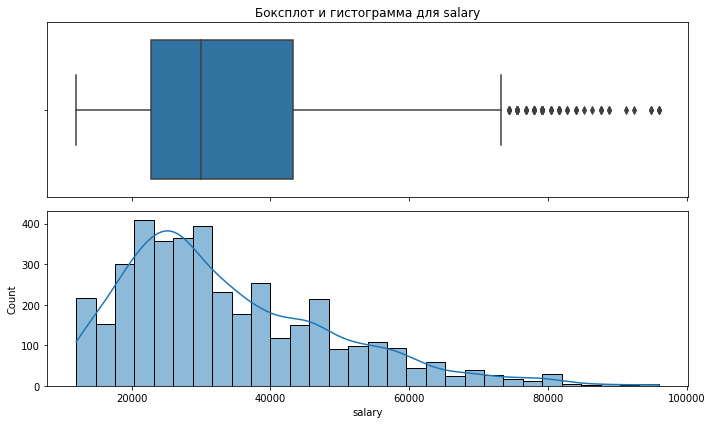

In [41]:
columns = ['salary']
for column in columns:
    px_box(train_quit, column)

Видим уже знакомы нам признаки и их поведение

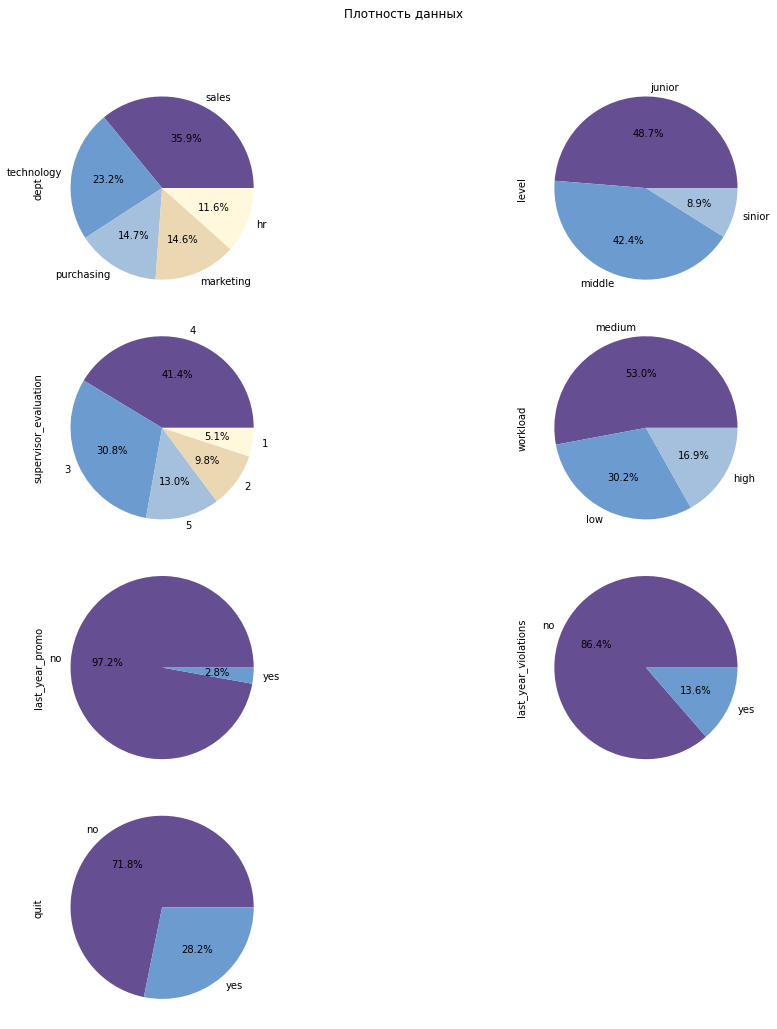

In [42]:
columns = ['dept', 'level', 'supervisor_evaluation',
       'workload', 'last_year_promo', 'last_year_violations', 'quit']
pastel_colors = ['#654E92', '#6C9BCF', '#A5C0DD', '#EBD8B2', '#FFF8DC', '#1C86EE']

fig, axs = plt.subplots(4, 2, figsize=(15, 15))
fig.suptitle('Плотность данных')
axs = axs.flatten()

for i, column in enumerate(columns):
    train_quit[column].value_counts().plot(kind='pie', ax=axs[i], colors=pastel_colors, autopct='%1.1f%%')
    axs[i].set_ylabel(column)  
fig.delaxes(axs[-1])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

<AxesSubplot:>

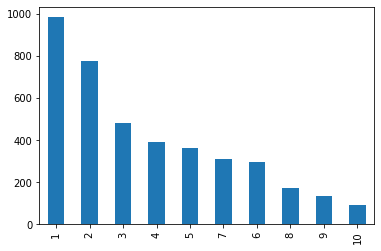

In [43]:
train_quit['employment_years'].value_counts().plot(kind='bar')

Посмотрим на так называемого Типичного уволившегося сотрудника

In [44]:
df = train_quit[train_quit['quit'] == 'yes']

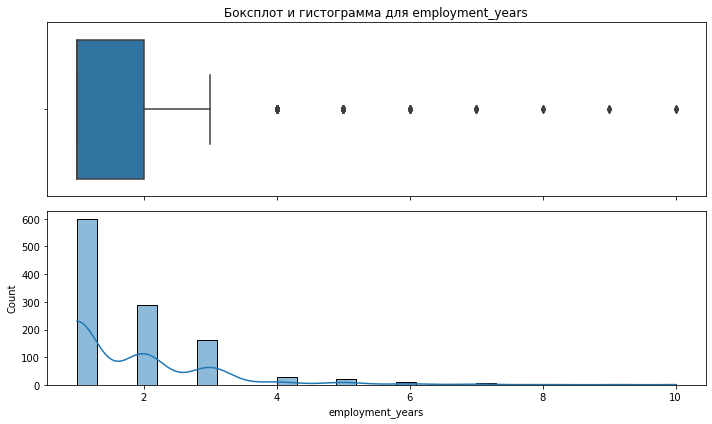

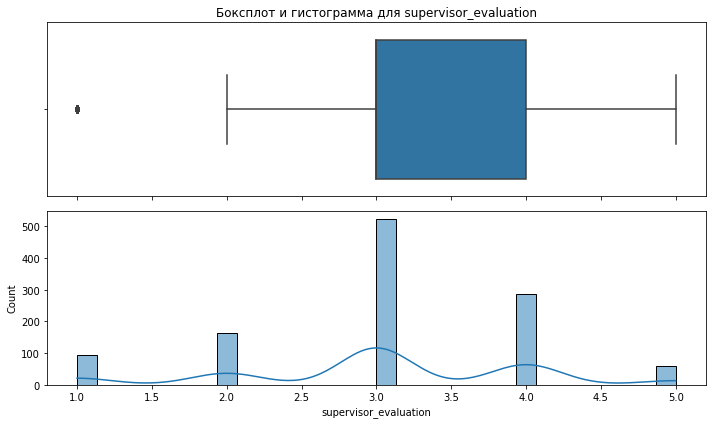

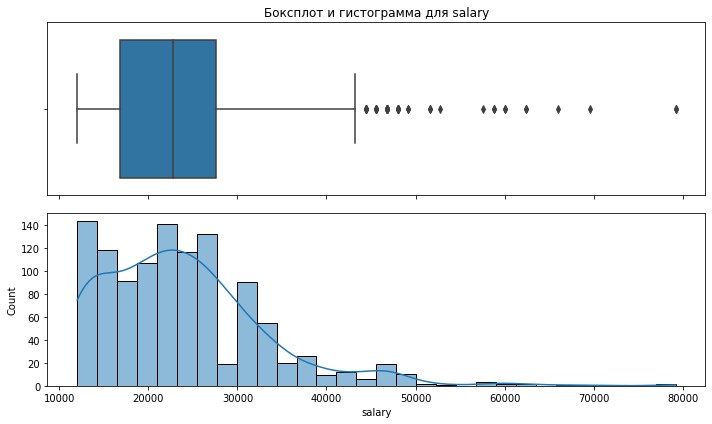

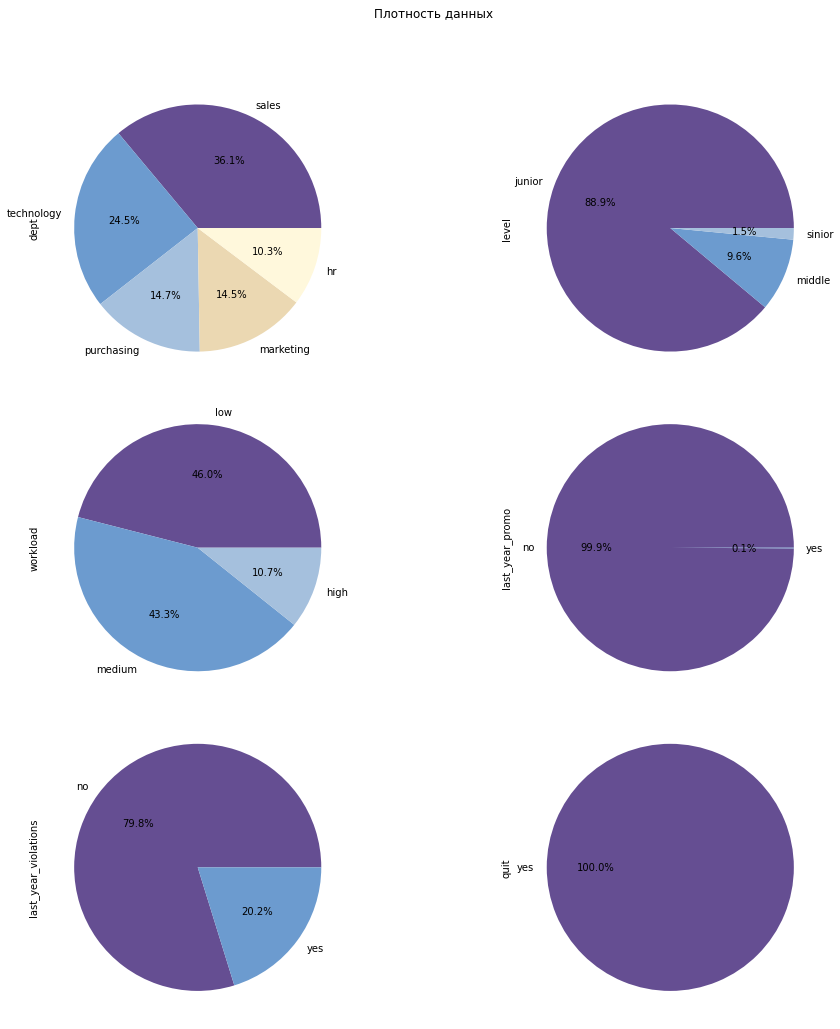

In [45]:
columns = ['employment_years', 'supervisor_evaluation',
       'salary']
for column in columns:
    px_box(df, column)
    
columns = ['dept', 'level',
       'workload', 'last_year_promo', 'last_year_violations', 'quit']
pastel_colors = ['#654E92', '#6C9BCF', '#A5C0DD', '#EBD8B2', '#FFF8DC', '#1C86EE']

fig, axs = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Плотность данных')
axs = axs.flatten()

for i, column in enumerate(columns):
    df[column].value_counts().plot(kind='pie', ax=axs[i], colors=pastel_colors, autopct='%1.1f%%')
    axs[i].set_ylabel(column)  
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

Итак, долгожданный результат результат:
- Уволившийся сотрудник, это в среднем, джуниор из отдела продаж или отдела техналогий, с низкой или средней, не получавший повышения заработной платы и за ним зачастую можно найти нарушение трудового договора

Визуализируем взаимодействие признака удовлетворённости своей работой и признака увоился ли сотрудник

In [46]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1999 entries, 1733 to 334
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   1997 non-null   object 
 1   level                  1998 non-null   object 
 2   workload               1999 non-null   object 
 3   employment_years       1999 non-null   float64
 4   last_year_promo        1999 non-null   object 
 5   last_year_violations   1999 non-null   object 
 6   supervisor_evaluation  1999 non-null   float64
 7   salary                 1999 non-null   float64
dtypes: float64(3), object(5)
memory usage: 140.6+ KB


In [47]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1999 non-null   float64
 1   dept                   1997 non-null   object 
 2   level                  1998 non-null   object 
 3   workload               1999 non-null   object 
 4   employment_years       1999 non-null   float64
 5   last_year_promo        1999 non-null   object 
 6   last_year_violations   1999 non-null   object 
 7   supervisor_evaluation  1999 non-null   float64
 8   salary                 1999 non-null   float64
dtypes: float64(4), object(5)
memory usage: 140.8+ KB


In [48]:
X_test = test_features.drop(['id'], axis=1)
X_test.fillna(X_test.mean(), inplace=True)
#X_test['employment_years'] = X_test['employment_years'].astype('Int32')
#X_test['supervisor_evaluation'] = X_test['supervisor_evaluation'].astype('Int32')
#X_test['salary'] = X_test['salary'].astype('Int32')
test_features['job_satisfaction_rate'] = grid_searchCV.predict(X_test)
test_features['job_satisfaction_rate'] = test_features['job_satisfaction_rate'].round(2)
merge = pd.merge(test_features, test_target_quit, on='id')

In [49]:
quit_0 = merge[merge['quit'] == 'no']
quit_1 = merge[merge['quit'] == 'yes']

In [50]:
quit_0

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,485046.0,marketing,junior,medium,2.0,no,no,5.0,28800.0,0.80,no
1,686555.0,hr,junior,medium,1.0,no,no,4.0,30000.0,0.70,no
2,467458.0,sales,middle,low,5.0,no,no,4.0,19200.0,0.60,no
3,418655.0,sales,middle,low,6.0,no,no,4.0,19200.0,0.65,no
4,789145.0,hr,middle,medium,5.0,no,no,5.0,40800.0,0.68,no
7,500791.0,sales,middle,high,9.0,no,no,4.0,49200.0,0.72,no
8,767867.0,marketing,middle,high,3.0,no,yes,4.0,62400.0,0.58,no
11,473072.0,hr,middle,medium,1.0,no,no,4.0,36000.0,0.49,no
12,984128.0,sales,middle,medium,5.0,no,no,3.0,33600.0,0.32,no
13,252146.0,marketing,middle,low,7.0,no,yes,1.0,19200.0,0.24,no


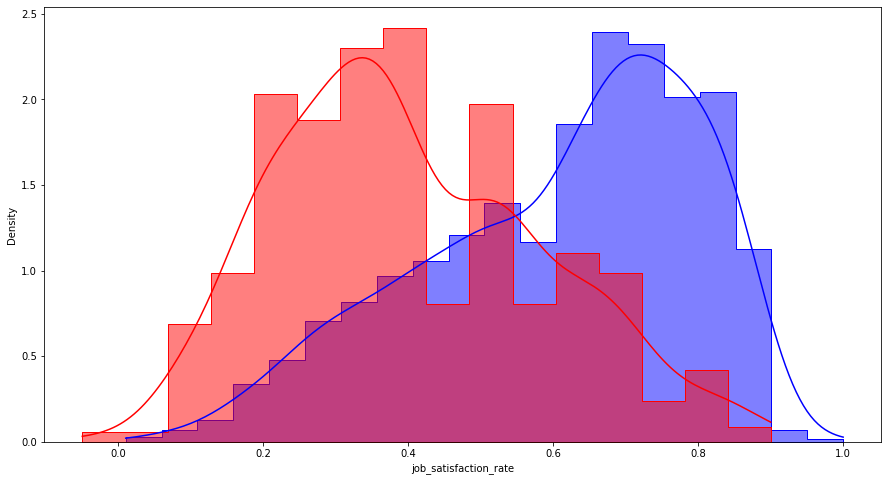

In [51]:
plt.figure(figsize=(15, 8))
sns.histplot(data=quit_0, x='job_satisfaction_rate', kde=True, element='step', stat='density', color="blue");
sns.histplot(data=quit_1, x='job_satisfaction_rate', kde=True, element='step', stat='density', color="red");

Можем увидеть, что большое значение удовлетворённостью работы не можеь гарантировать того что человек не уволится, однако у всех сотрудников которые остались, уровень удовлетворённости в среднем от 0,6 до 0,9, а у уволившихся от 0,2 до 0,6.

## Обучение модели

Для начала вновь определим столбцы

In [52]:
ohe_columns = ['dept']
ord_columns = ['level', 'workload', 'last_year_promo', 'last_year_violations']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

Теперь определим выборки

In [53]:
X_train = train_quit.drop(['id', 'quit'], axis=1)
y_train = train_quit['quit']
#X_test = pd.merge(test_features, test_target_job_satisfaction, on='id')
X_test = test_features
y_test = test_target_quit
merged = pd.merge(y_test, X_test, on='id')
merged = merged.sort_values(by='id')
X_test = merged.drop(['id', 'quit'], axis=1)
y_test = merged['quit']

In [54]:
X_train['job_satisfaction_rate'] = grid_searchCV.predict(X_train)
X_train1 = X_train

In [55]:
ohe_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse=False)),
    ('simpleImputer_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        categories=[
            ['junior', 'middle', 'sinior'], 
            ['low', 'medium', 'high'],
            ['no', 'yes'],
            ['no', 'yes']], 
        handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, ohe_columns),  
        ('ord', ord_pipe, ord_columns),    
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))])
param_grid = [
    {
        'models': [DecisionTreeClassifier(random_state=42)],
        'models__criterion': ["gini", "entropy"],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, len(num_columns) + 1),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1,15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    },
    {
        'models': [SVC(probability=True, random_state=RANDOM_STATE)],
        'models__C': [0.1, 1, 5],
        'models__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    }
]        
   
grid_searchCV = GridSearchCV(
    pipe_final,
    param_grid,
    cv=10,
    scoring='roc_auc',  
    n_jobs=-1,
    error_score = 'raise'
)

Пайплайн собран, гридсёрч настроен, выполним обучение

In [56]:
grid_searchCV.fit(X_train, y_train)

GridSearchCV(cv=10, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_before_ord',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        sparse=False)),
                                                                                         ('simpleImputer_after_ohe',
                                      

In [57]:
print('Лучшая модель и её параметры:\n\n', grid_searchCV.best_estimator_)
print ('Метрика лучшей модели на кросс валидации:', grid_searchCV.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept']),
                                                 ('ord',
                         

По итогу кросс валидации определена лучшая модель, ей оказалась модель SVC с С=1, посмотрим на результаты других моделей

In [58]:
result = pd.DataFrame(grid_searchCV.cv_results_)
display(result.sort_values('rank_test_score').head(5)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__criterion,param_models__max_depth,param_models__max_features,param_preprocessor__num,param_models__n_neighbors,param_models__C,param_models__kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
83,0.951708,0.028917,0.030323,0.001924,"SVC(C=1, probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,1,rbf,"{'models': SVC(C=1, probability=True, random_state=42), 'models__C': 1, 'models__kernel': 'rbf', 'preprocessor__num': MinMaxScaler()}",0.910249,0.934586,0.904135,0.941167,0.922620,0.919768,0.912198,0.930622,0.928849,0.957988,0.926218,0.015241,1
80,0.781387,0.014620,0.022001,0.003524,"SVC(C=1, probability=True, random_state=42)",NaN,NaN,NaN,StandardScaler(),NaN,1,poly,"{'models': SVC(C=1, probability=True, random_state=42), 'models__C': 1, 'models__kernel': 'poly', 'preprocessor__num': StandardScaler()}",0.923952,0.915644,0.905276,0.942462,0.910656,0.923807,0.921880,0.930406,0.922312,0.954658,0.925105,0.013840,2
91,0.956619,0.039233,0.030052,0.003517,"SVC(C=1, probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,5,rbf,"{'models': SVC(C=1, probability=True, random_state=42), 'models__C': 5, 'models__kernel': 'rbf', 'preprocessor__num': MinMaxScaler()}",0.912698,0.911892,0.904412,0.944868,0.916145,0.920354,0.914757,0.933890,0.924224,0.959129,0.924237,0.016079,3
82,0.922463,0.035502,0.030013,0.002344,"SVC(C=1, probability=True, random_state=42)",NaN,NaN,NaN,StandardScaler(),NaN,1,rbf,"{'models': SVC(C=1, probability=True, random_state=42), 'models__C': 1, 'models__kernel': 'rbf', 'preprocessor__num': StandardScaler()}",0.907583,0.913194,0.903395,0.934230,0.918488,0.922728,0.929311,0.927569,0.929466,0.954010,0.923998,0.013852,4
81,0.888733,0.033861,0.022074,0.003025,"SVC(C=1, probability=True, random_state=42)",NaN,NaN,NaN,MinMaxScaler(),NaN,1,poly,"{'models': SVC(C=1, probability=True, random_state=42), 'models__C': 1, 'models__kernel': 'poly', 'preprocessor__num': MinMaxScaler()}",0.913349,0.932478,0.893774,0.933551,0.917810,0.927292,0.907080,0.932287,0.917903,0.963692,0.923922,0.017908,5


Можем заметить что в результате обучения подходит именно модель SVC (топ-5 все SVC) c различными ядрами (rbf и poly) разница ответов едва ли заметна 

In [59]:
y_test_proba = grid_searchCV.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_proba)}')

Метрика ROC-AUC на тестовой выборке: 0.9256919218128351


Отличный результат, эта модель так же сответствует ожиданиям заказчика

### Анализ признаков

Для анализа признаков нам нужна новая модель, это связанно с плохой адаптацией библиотеки shap и SVC, Knn, Shap в основном используют на лёгких моделях, учитывая то что у нас используется сложная модель, пайплайн и гридсёрч, есть больщая вероятность что это не получится всё совместить для реализации

Для анализа признаков обучим модель логистической регрессии и посмотрим на значимость признаков

In [88]:
X_train = X_train1
y_train = train_quit['quit']
#X_test = pd.merge(test_features, test_target_job_satisfaction, on='id')
X_test = test_features
y_test = test_target_quit
merged = pd.merge(X_test, y_test, on='id', how='inner')
merged = merged.sort_values(by='id')
X_test = merged.drop(['id', 'quit'], axis=1)
y_test = merged['quit']

ohe_columns = ['dept']
ord_columns = ['level', 'workload', 'last_year_promo', 'last_year_violations']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']

ohe_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse=False)),
    ('simpleImputer_after_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

ord_pipe = Pipeline([
    ('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(
        categories=[
            ['junior', 'middle', 'sinior'], 
            ['low', 'medium', 'high'],
            ['no', 'yes'],
            ['no', 'yes']], 
        handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
])

data_preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', ohe_pipe, ohe_columns),  
        ('ord', ord_pipe, ord_columns),    
        ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))])
pipe_final.fit(X_train, y_train)
param_grid = [
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'models__C': range(1,15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]
    }
]        
   
grid_searchCV = GridSearchCV(
    pipe_final,
    param_grid,
    cv=10,
    scoring='roc_auc',  
    n_jobs=-1,
    error_score = 'raise'
)

grid_searchCV.fit(X_train, y_train)
print('Лучшая модель и её параметры:\n\n', grid_searchCV.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', grid_searchCV.best_score_)
y_test_proba = grid_searchCV.predict_proba(X_test)[:, 1]
print(f'Метрика ROC-AUC на тестовой выборке: {roc_auc_score(y_test, y_test_proba)}')
result = pd.DataFrame(grid_searchCV.cv_results_)
display(result.sort_values('rank_test_score').head(3)) 

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['dept']),
                                                 ('ord',
                         

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_models,param_models__C,param_preprocessor__num,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
3,0.398948,0.076428,0.111244,0.026453,"LogisticRegression(C=2, random_state=42)",2,MinMaxScaler(),"{'models': LogisticRegression(C=2, random_state=42), 'models__C': 2, 'preprocessor__num': MinMaxScaler()}",0.916822,0.934958,0.884709,0.922019,0.921048,0.908421,0.896010,0.923746,0.911304,0.941923,0.916096,0.016161,1
5,0.461189,0.197449,0.092512,0.061281,"LogisticRegression(C=2, random_state=42)",3,MinMaxScaler(),"{'models': LogisticRegression(C=2, random_state=42), 'models__C': 3, 'preprocessor__num': MinMaxScaler()}",0.916915,0.935454,0.884092,0.921896,0.921140,0.908760,0.895671,0.923622,0.911366,0.941645,0.916056,0.016314,2
1,0.292034,0.068262,0.157447,0.045171,"LogisticRegression(C=2, random_state=42)",1,MinMaxScaler(),"{'models': LogisticRegression(C=2, random_state=42), 'models__C': 1, 'preprocessor__num': MinMaxScaler()}",0.916295,0.934307,0.885603,0.921341,0.921325,0.907157,0.896288,0.924177,0.911828,0.942108,0.916043,0.015965,3


В результате мы имеем вполне хорошую и качественную модель, которая слегка уступает SVC, преобразуем выборки и применим shap

In [89]:
shap.initjs()

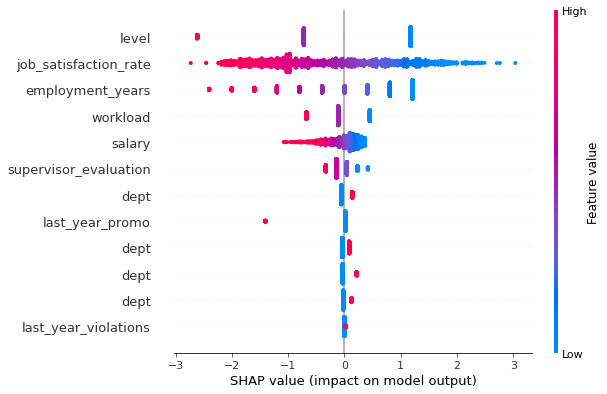

None

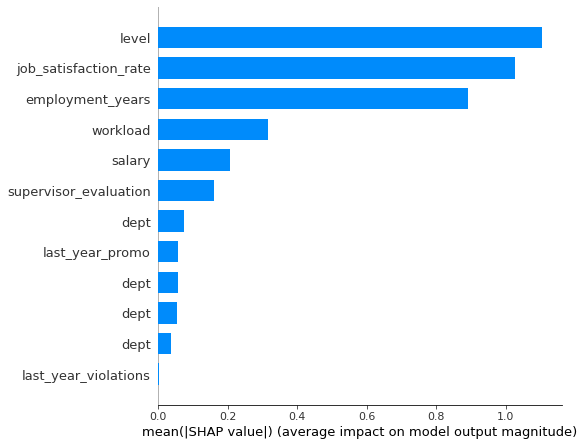

In [90]:
X_train_2 = pipe_final.named_steps['preprocessor'].fit_transform(X_train)
X_test_2 = pipe_final.named_steps['preprocessor'].transform(X_test)
feature_names = ['dept',
                 'dept',
                 'dept',
                 'dept',
                 'level',
                 'workload',
                 'last_year_promo',
                 'last_year_violations',
                 'employment_years',
                 'supervisor_evaluation',
                 'salary',
                 'job_satisfaction_rate']
X_test_2 = pd.DataFrame(X_test_2, columns=feature_names)
explainer = shap.LinearExplainer(grid_searchCV.best_estimator_.named_steps['models'], X_train_2)
shap_values = explainer(X_test_2)

display(shap.plots.beeswarm(shap_values, max_display=20))
shap.summary_plot(shap_values, plot_type='bar') 

In [ ]:
print("Метки классов:", grid_searchCV.best_estimator_.classes_)

Чтоже, судя по графику, на целевой признак уволился ли человек, практически никак не влияет департамент, были ли нарушения и было ли повышение, однако очень важно знать точные данные по признакам уровень сотрудника, показатель удовлетворённости, стаж и нагрузку, будет прекрасным дополнением если известен уровень заработной платы

Вывод: лучше всего справилась модель SVC, в данных множество различных числовых значений, взаимосвязь между ними помогают уловить именно опорные вектора, благодаря чему мы и выбрали SVC.

Признаки имеют важное значение для целевого признака, крайне важными оказались такие признаки как удовлетворённость работой, уровень струдника, нагрузки сотрудника стаж и заработная плата, Однако совсем лишний признак о наличии нарушений трудового договора и департамент а так же повышали ли заработную плату, лишние признаки могут усложнить модель и вносить шум, однако точность важных признаков, гарантирует более качественные результаты

## Итоговый вывод:

В данном проекте мы решали две задачи:
1) Прогнозиование уровня удовлетворённости

2) Прогнозирование вероятность увольнения сотрудника

Выполнили этапы:
* 1) Загрузка данных и первичный анализ
* 2) предобработка данных
** Данные находятся в почти идиальном состоянии, единственное что их портит это наличие пропусков, заполним их вдальнейшем с помощью пайплайна
* 3) Исследовательский анализ
- для признака Уровень профессионализма:
** при уровне джуниор и при любой загруженности сотрудники преимущественно имеют среднюю лояльность, вероятно это связанно с неопытностью в данной сфере или связанно с адаптацией к этой компании, сотрудник не может рационально оценить, что из его работы имеет смысл быть, а что из ряда вон
** при уровне мидл при слабой нагрузке имеют высокую лояльность, очевидный человеческий фактор
** при мидл и высокой нагрузке 50/50 средней и высокой лояльности, в этом подразделе можно выделить ссотрудников которые очень любят свою работу/компанию и имеют высокий КПД, при средней нагрузке, лояльность сбалансированна в примерно равных долях
** так же есть только джуниоры которые не получали повышение зп, возможно это связанно с возможным наличием стажировок или если например при повышении зарпталы сотрудника переводят на следующий уровень
** для мидл, как только сотрудники получали повышение, стали иметь высокую лояльность, явный человеческий фактор
все сеньёры по большей степени имеют высокую лояльность в независимости от повышения, это связанно с тем что до этого уровня доходит далеко не каждый сотрудник, а доходят только те кто действительно любит эту работу и проявляет высокий уровень своей компитенции
- для признака Уровень загруженности:
** При повышении заработной платы сотрудники всех видов загруженности имеют высокую лояльность, Человеческий фактор
** При средней загруженности и отсутствии повышения заработной платы, сотрудники имеют преимущественно низкую лояльность, а при высокой нагруженности и отсутвии повышение преимущественно среднюю лояльность, это можно обьяснить так, при средней загруженности сотрудники могут сравнивать свою работу с работой других и видеть, что они не получают достаточной компенсации за свои усилия, что снижает их лояльность. При высокой загруженности они могут чувствовать, что их усилия более значимы, даже если они не получают за это материального вознаграждения или же сотрудники, работающие в условиях высокой нагрузки, могут чувствовать большую ответственность за свою работу и команду, что может способствовать формированию определенной лояльности. Однако эта лояльность может быть неустойчивой и зависеть от общей атмосферы в коллективе и уровня стресса.
- для признака наличия нарушений:
** сотрудники у которых были выявленны нарушения, с большим преимуществом имеют низкую лояльность и среднюю лояльность (тут можно разделить сотрудников с средней лояльностью на ответственных и не ответственных), человеческий фактор
** сотрудники у которых нарушений не выявленно, с большим преимуществом имеют высоку лояльность и среднюю лояльность (тут как раз ответственные сотрудники с средней лояльностью)
- для признака оценка от руководителя:
** руководитель равномерно и непредвзято оценивает все возрасты
** чем выше оценка руководителя, тем выше лояльность, человеческий фактор
- для признака заработная плата:
** чем выше уровень профессионализма и выше загруженность сотрудника тем выше смещается интервал зарплат
- для признака повышения з\п:
** тот факт что произошло повышение заработной платы, увеличивает лояльность сотрудников
- Для признака заработная плата, можем увидеть, что при повышении уровня профессионализма и рабочей нагрузки вместе с ними растёт и заработная плата
- Для признаков оценка руководителя и уровень лояльности, замечен интересный факт, если для низкого и высокого уроврня лояльности, оценка руководителя влияет не сильно, то для среднего уровня лояльности он проявляет своё максимальное взаимодействие на этот признак, это взаимодействие более вырозительно из-за того что средняя лояльность это мажорный класс признака
* 4) Обучили и подобрали модель для решения первой задачи
** Для достойного предсказания, найдена модель, которая предсказывает значение целевого признака такого как удовлетворённость работой у сотрудника, это безусловно важная задача, ведь благодаря этому можно предотвратить отток кадров и избежать их текучки, лучше всего справилась модель SVR c ядром 'rbf', её метрика равняется smape = 13,5 что является отличным показателем
* 5) Загрузка новых данных для решения второй задачи
** пропусков не обнаруженно
* 6) Предобработка данных
** Полных дубликатов не обнаруженно. Датасет в прекрасном состоянии
* 7) Исследовательский анализ новых данных
** Типичный уволившийся сотрудник, это в среднем, джуниор из отдела продаж или отдела техналогий, с низкой или средней, не получавший повышения заработной платы и за ним зачастую можно найти нарушение трудового договора
** Новые данные повторяют поведение уже изученных ранее данных, добавился только новый признак
** Можем увидеть, что большое значение удовлетворённостью работы не можеь гарантировать того что человек не уволится, однако у всех сотрудников которые остались, уровень удовлетворённости в среднем от 0,6 до 0,9, а у уволившихся от 0,2 до 0,6.
* 8) Обучили новую модель для решения второй задачи
** Лучше всего справилась модель SVC, в данных множество различных числовых значений, взаимосвязь между ними помогают уловить именно опорные вектора, благодаря чему мы и выбрали SVC.
** Признаки имеют важное значение для целевого признака, крайне важными оказались такие признаки как удовлетворённость работой, уровень струдника, нагрузки сотрудника стаж и заработная плата, Однако совсем лишний признак о наличии нарушений трудового договора и департамент а так же повышали ли заработную плату, лишние признаки могут усложнить модель и вносить шум, однако точность важных признаков, гарантирует более качественные результаты

Рекоминдации для бизнеса, данные имеют минимально необходимый набор данных для реализации и полноценного предсказания значений или событий, очень важно обратить внимание на такие признаки как удовлетворённость работой, уровень струдника, нагрузки сотрудника стаж и заработная плата, это ключивые признаки, на основе которых делается предсказание, однако если уровень удовлетворённости нам не известен можно так же использовать первую модель, она справится с этим давольно хорошо.
Данные модели помогут выяснить ключевые моменты для сотрудникаЮ что может мешать его конечому настрою в качестве работы, а так же поддерживать микроклимат сотрудников при их улучшении, что в конечном итоге предотвращает отток кадров